# 🔏 IBW Watermarking — Size Sweep Edition (v3)
**Based on:** Sardroudi & Ibrahim (2010)

**What this notebook adds over v2:**
- Cells 1–5 are identical to v2 (install, params, load data, core functions, 8×8 sanity check)
- **Cell 6 (NEW):** Sweeps watermark sizes from 12×12 → 255×255, measuring for each:
  - Pixel coverage %
  - Mean hits per pixel
  - CF before recovery
  - CF after recovery
  - CF gain from recovery (after − before)
- Identifies and marks the **optimal size** (maximum CF after recovery)
- Cells 7–12 run the full pipeline at the optimal size

---
### Sizes tested
```
12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255
```
Each size S means an S×S binarized matrix = S² pixels to embed.

In [ ]:
# ── CELL 1 — Install ─────────────────────────────────────
!pip install openpyxl pillow pandas numpy tqdm --quiet

In [6]:
# ── CELL 2 — Imports & Parameters ────────────────────────
import pandas as pd
import numpy as np
import hashlib, math, warnings, time
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# ── USER PARAMETERS ──────────────────────────────────────
SECRET_KEY  = "walmart_ibw_2024"
F           = 5
NUM_LSB     = 4
NUM_MSB     = 2
# ─────────────────────────────────────────────────────────

MEASURE_COLS = ['DURATION_OF_STAY', 'ICU_STAY', 'HB', 'CREATININE']
MEASURE_SCALE = {
    'DURATION_OF_STAY': 1,
    'ICU_STAY': 1,
    'HB': 100,
    'CREATININE': 1000
}
NUM_A = len(MEASURE_COLS)

# Sizes to sweep — covers 12×12 up to 255×255
SWEEP_SIZES = [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

print("✅ Parameters ready.")
print(f"   Sweep sizes : {SWEEP_SIZES}")

✅ Parameters ready.
   Sweep sizes : [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]


In [2]:
# ── CELL 3 — Load Dataset ────────────────────────────────
from google.colab import files
print("📂 Upload walmart_Retail_Data.xlsx")
print("📂 Upload HDHI Admission data CSV")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]

KEEP_COLS = {
    'D.O.A': 'DOA',
    'GENDER': 'GENDER',
    'RURAL': 'RURAL',
    'TYPE OF ADMISSION-EMERGENCY/OPD': 'ADMISSION_TYPE',
    'DURATION OF STAY': 'DURATION_OF_STAY',
    'duration of intensive unit stay': 'ICU_STAY',
    'HB': 'HB',
    'CREATININE': 'CREATININE'
}

df_raw = pd.read_csv(csv_name)
df = df_raw[list(KEEP_COLS.keys())].copy()
df.rename(columns=KEEP_COLS, inplace=True)

df['DOA'] = pd.to_datetime(df['DOA'], errors='coerce')
for c in ['DURATION_OF_STAY', 'ICU_STAY', 'HB', 'CREATININE']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['DOA', 'GENDER', 'RURAL', 'ADMISSION_TYPE',
                       'DURATION_OF_STAY', 'ICU_STAY', 'HB', 'CREATININE']).reset_index(drop=True)

df.insert(0, 'pk', range(1, len(df)+1))
df_original = df.copy()
df_original.to_csv('original_hospital.csv', index=False)
print(f"✅ Loaded {len(df)} rows × {len(df.columns)} columns")
display(df.head(3))

📂 Upload walmart_Retail_Data.xlsx
📂 Upload HDHI Admission data CSV


Saving HDHI Admission data.csv to HDHI Admission data.csv
✅ Loaded 9841 rows × 9 columns


,pk,DOA,GENDER,RURAL,ADMISSION_TYPE,DURATION_OF_STAY,ICU_STAY,HB,CREATININE
0,1,2017-04-01,M,R,E,3,2,9.5,0.9
1,2,2017-04-01,M,R,E,5,2,13.7,0.9
2,3,2017-04-01,M,U,E,3,3,10.6,2.3


🖼️  Upload your B&W watermark image (JPEG/PNG)


Saving watermark.jpeg to watermark.jpeg
✅ Loaded image: watermark.jpeg
   Original size : 447 × 447 px


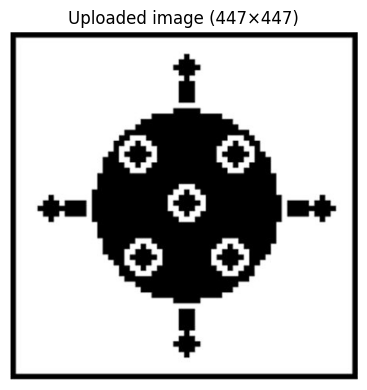

In [3]:
# ── CELL 4 — Upload Watermark Image (stored raw, resized per sweep)
print("🖼️  Upload your B&W watermark image (JPEG/PNG)")
uploaded_img = files.upload()
img_name     = list(uploaded_img.keys())[0]

# Store the original PIL image — we will resize it freshly for each sweep size
IMG_PIL_ORIG = Image.open(img_name).convert('L')
print(f"✅ Loaded image: {img_name}")
print(f"   Original size : {IMG_PIL_ORIG.width} × {IMG_PIL_ORIG.height} px")

plt.figure(figsize=(4, 4))
plt.imshow(IMG_PIL_ORIG, cmap='gray')
plt.title(f'Uploaded image ({IMG_PIL_ORIG.width}×{IMG_PIL_ORIG.height})')
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 5 — Core Functions (Hospital Dataset Version) ───────────

def compute_vpk(pk, secret_key):
    return int(hashlib.md5(f"{pk}{secret_key}".encode()).hexdigest(), 16)

def compute_pixel_coord(vpk, img_h, img_w):
    h = int(hashlib.md5(f"{vpk}_h".encode()).hexdigest(), 16) % img_h
    w = int(hashlib.md5(f"{vpk}_w".encode()).hexdigest(), 16) % img_w
    return h, w

def select_msb_bit(vpk, value, num_msb):
    if value <= 0: return 0
    msb_pos = max(value.bit_length() - 1 - (vpk % num_msb), 0)
    return (value >> msb_pos) & 1

def get_lsb(value, bit_pos):
    return (value >> (bit_pos - 1)) & 1

def set_lsb(value, bit_pos, bit_val):
    mask = 1 << (bit_pos - 1)
    return (value & ~mask) | (bit_val << (bit_pos - 1))

def minimize_variation(orig, modified, marked_bit_pos, num_lsb):
    best_val, best_diff = modified, abs(orig - modified)
    for bp in range(1, num_lsb + 1):
        if bp == marked_bit_pos: continue
        for bv in (0, 1):
            c = set_lsb(modified, bp, bv)
            d = abs(orig - c)
            if d < best_diff:
                best_diff, best_val = d, c
    return best_val

def value_tolerable(value, num_lsb):
    return value > 0 and value.bit_length() > (2 * num_lsb)


# ── Pre-compute VPK table ───────────────────────────────
print("⚙️  Pre-computing VPK table for all rows...")

VPK_TABLE = {}
RAW_TABLE = {}

for idx, row in df_original.iterrows():
    pk  = int(row['pk'])
    vpk = compute_vpk(pk, SECRET_KEY)
    VPK_TABLE[pk] = vpk

    if vpk % F != 0:
        RAW_TABLE[pk] = None
        continue

    attr_name = MEASURE_COLS[vpk % NUM_A]
    bit_pos   = (vpk % NUM_LSB) + 1

    raw_val = int(round(float(row[attr_name]) * MEASURE_SCALE[attr_name]))

    RAW_TABLE[pk] = (
        attr_name,
        bit_pos,
        raw_val,
        value_tolerable(raw_val, NUM_LSB)
    )

ELIGIBLE_PKS = [pk for pk, v in RAW_TABLE.items() if v is not None and v[3]]

print(f"✅ VPK table ready. Eligible (markable) rows: {len(ELIGIBLE_PKS)} / {len(df_original)}")


# ── EMBEDDING ───────────────────────────────────────────
def embed_fast(wm_matrix, img_h, img_w):

    df_out    = df_original.copy()
    pixel_hit = np.zeros((img_h, img_w), dtype=np.int32)
    marked    = 0

    for pk in ELIGIBLE_PKS:
        vpk = VPK_TABLE[pk]
        attr_name, bit_pos, raw_val, _ = RAW_TABLE[pk]

        h, w    = compute_pixel_coord(vpk, img_h, img_w)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)

        new_bit = int(wm_matrix[h, w]) ^ msb_bit

        new_val = minimize_variation(
            raw_val,
            set_lsb(raw_val, bit_pos, new_bit),
            bit_pos,
            NUM_LSB
        )

        idx   = pk - 1
        scale = MEASURE_SCALE[attr_name]

        if scale == 1:
            df_out.at[idx, attr_name] = int(new_val)
        else:
            df_out.at[idx, attr_name] = round(new_val / scale, 3 if scale == 1000 else 2)

        pixel_hit[h, w] += 1
        marked += 1

    return df_out, pixel_hit, marked


# ── EXTRACTION ───────────────────────────────────────────
def extract_fast(df_wm, img_h, img_w):

    ones  = np.zeros((img_h, img_w), dtype=np.int32)
    total = np.zeros((img_h, img_w), dtype=np.int32)

    for pk in ELIGIBLE_PKS:
        vpk = VPK_TABLE[pk]
        attr_name, bit_pos, _, _ = RAW_TABLE[pk]

        idx = pk - 1

        # 🔥 FIXED: generic measure-based extraction
        scale = MEASURE_SCALE[attr_name]
        raw_val = int(round(float(df_wm.at[idx, attr_name]) * scale))

        if not value_tolerable(raw_val, NUM_LSB):
            continue

        h, w = compute_pixel_coord(vpk, img_h, img_w)

        ext_lsb = get_lsb(raw_val, bit_pos)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)

        ones[h, w]  += (ext_lsb ^ msb_bit)
        total[h, w] += 1

    ext_wm = np.zeros((img_h, img_w), dtype=np.uint8)
    m = total > 0
    ext_wm[m] = (ones[m] >= (total[m] / 2.0)).astype(np.uint8)

    return ext_wm, total


# ── RECOVERY ─────────────────────────────────────────────
def recover_image(wm, total_count):

    recovered = wm.copy()
    missing   = total_count == 0

    if not missing.any():
        return recovered

    img_h, img_w = wm.shape

    for i in range(img_h):
        for j in range(img_w):
            if not missing[i, j]:
                continue

            nbrs = [
                int(recovered[i+di, j+dj])
                for di in [-1, 0, 1]
                for dj in [-1, 0, 1]
                if not (di == 0 and dj == 0)
                and 0 <= i+di < img_h
                and 0 <= j+dj < img_w
                and not missing[i+di, j+dj]
            ]

            if nbrs:
                recovered[i, j] = 1 if sum(nbrs) >= len(nbrs)/2 else 0
            else:
                si, sj = img_h-1-i, img_w-1-j
                if not missing[si, sj]:
                    recovered[i, j] = recovered[si, sj]

    return recovered


# ── METRIC ───────────────────────────────────────────────
def correction_factor(orig, extracted):
    return 100.0 * np.sum(
        np.bitwise_xor(orig.astype(np.uint8),
                       extracted.astype(np.uint8)) == 0
    ) / orig.size


print("✅ All core functions ready (Hospital version).")

⚙️  Pre-computing VPK table for all rows...
✅ VPK table ready. Eligible (markable) rows: 927 / 9841
✅ All core functions ready (Hospital version).


In [8]:
# ── CELL 6 — SIZE SWEEP (12×12 → 255×255) ────────────────
#
# For each size S in SWEEP_SIZES:
#   1. Resize the uploaded JPEG to S×S
#   2. Binarize (threshold 127)
#   3. Embed into the Walmart dataset
#   4. Extract immediately (no attack)
#   5. Run recovery
#   6. Compute CF before and after recovery
#   7. Record all stats
# Then find the optimal size (max CF after recovery)
# ─────────────────────────────────────────────────────────

sweep_records = []

print(f"🔁 Sweeping {len(SWEEP_SIZES)} sizes: {SWEEP_SIZES}")
print(f"   Eligible rows for marking : {len(ELIGIBLE_PKS)}\n")
print(f"{'Size':>8} | {'Pixels':>8} | {'Coverage%':>10} | {'MeanHits':>9} | "
      f"{'MinHits':>8} | {'Missing':>8} | {'CF_before':>10} | {'CF_after':>9} | {'Gain':>6} | {'Time(s)':>8}")
print("-" * 115)

for S in tqdm(SWEEP_SIZES, desc="Size sweep"):
    t0 = time.time()

    # ── Step 1: Resize + binarize ──────────────────────────
    img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
    wm_matrix   = (np.array(img_resized) > 127).astype(np.uint8)
    total_px    = S * S

    # ── Step 2: Embed ──────────────────────────────────────
    df_wm, pixel_hit, marked_count = embed_fast(wm_matrix, S, S)

    # ── Step 3: Extract ────────────────────────────────────
    ext_raw, hit_counts = extract_fast(df_wm, S, S)

    # ── Step 4: Recovery ───────────────────────────────────
    ext_recovered = recover_image(ext_raw, hit_counts)

    # ── Step 5: Metrics ────────────────────────────────────
    pixels_hit   = int((hit_counts > 0).sum())
    pixels_miss  = total_px - pixels_hit
    coverage_pct = 100.0 * pixels_hit / total_px
    mean_hits    = float(pixel_hit.mean())
    min_hits     = int(pixel_hit.min())
    cf_b         = correction_factor(wm_matrix, ext_raw)
    cf_a         = correction_factor(wm_matrix, ext_recovered)
    gain         = cf_a - cf_b
    elapsed      = time.time() - t0

    sweep_records.append({
        'size'        : S,
        'total_pixels': total_px,
        'pixels_hit'  : pixels_hit,
        'pixels_miss' : pixels_miss,
        'coverage_pct': round(coverage_pct, 2),
        'mean_hits'   : round(mean_hits, 2),
        'min_hits'    : min_hits,
        'cf_before'   : round(cf_b, 4),
        'cf_after'    : round(cf_a, 4),
        'cf_gain'     : round(gain, 4),
        'marked_rows' : marked_count,
        'elapsed_s'   : round(elapsed, 1),
    })

    print(f"{S:>5}×{S:<3}| {total_px:>8,} | {coverage_pct:>9.2f}% | "
          f"{mean_hits:>9.2f} | {min_hits:>8} | {pixels_miss:>8} | "
          f"{cf_b:>9.2f}% | {cf_a:>8.2f}% | {gain:>+5.2f}% | {elapsed:>7.1f}s")

sweep_df = pd.DataFrame(sweep_records)
sweep_df.to_csv('size_sweep_results.csv', index=False)

# ── Find optimal ───────────────────────────────────────────
best_row  = sweep_df.loc[sweep_df['cf_after'].idxmax()]
BEST_SIZE = int(best_row['size'])

print("\n" + "═"*60)
print(f"  🏆 OPTIMAL SIZE : {BEST_SIZE}×{BEST_SIZE}")
print(f"     CF after recovery : {best_row['cf_after']:.4f}%")
print(f"     CF before recovery: {best_row['cf_before']:.4f}%")
print(f"     Recovery gain     : {best_row['cf_gain']:+.4f}%")
print(f"     Pixel coverage    : {best_row['coverage_pct']:.2f}%")
print(f"     Mean hits/pixel   : {best_row['mean_hits']:.2f}")
print(f"     Missing pixels    : {int(best_row['pixels_miss'])}")
print("═"*60)
print("\n✅ size_sweep_results.csv saved")

🔁 Sweeping 16 sizes: [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]
   Eligible rows for marking : 927

    Size |   Pixels |  Coverage% |  MeanHits |  MinHits |  Missing |  CF_before |  CF_after |   Gain |  Time(s)
-------------------------------------------------------------------------------------------------------------------


Size sweep:   0%|          | 0/16 [00:00<?, ?it/s]

   12×12 |      144 |    100.00% |      6.44 |        1 |        0 |    100.00% |   100.00% | +0.00% |     0.1s
   25×25 |      625 |     76.64% |      1.48 |        0 |      146 |     82.56% |    97.92% | +15.36% |     0.1s
   32×32 |    1,024 |     58.59% |      0.91 |        0 |      424 |     67.97% |    96.88% | +28.91% |     0.0s
   40×40 |    1,600 |     43.81% |      0.58 |        0 |      899 |     61.88% |    89.44% | +27.56% |     0.0s
   50×50 |    2,500 |     30.84% |      0.37 |        0 |     1729 |     52.04% |    88.64% | +36.60% |     0.0s
   64×64 |    4,096 |     20.29% |      0.23 |        0 |     3265 |     44.04% |    83.64% | +39.60% |     0.1s
   75×75 |    5,625 |     15.31% |      0.16 |        0 |     4764 |     39.09% |    79.95% | +40.85% |     0.0s
   90×90 |    8,100 |     10.81% |      0.11 |        0 |     7224 |     37.20% |    72.64% | +35.44% |     0.1s
  100×100|   10,000 |      8.79% |      0.09 |        0 |     9121 |     36.88% |    68.62% | +31

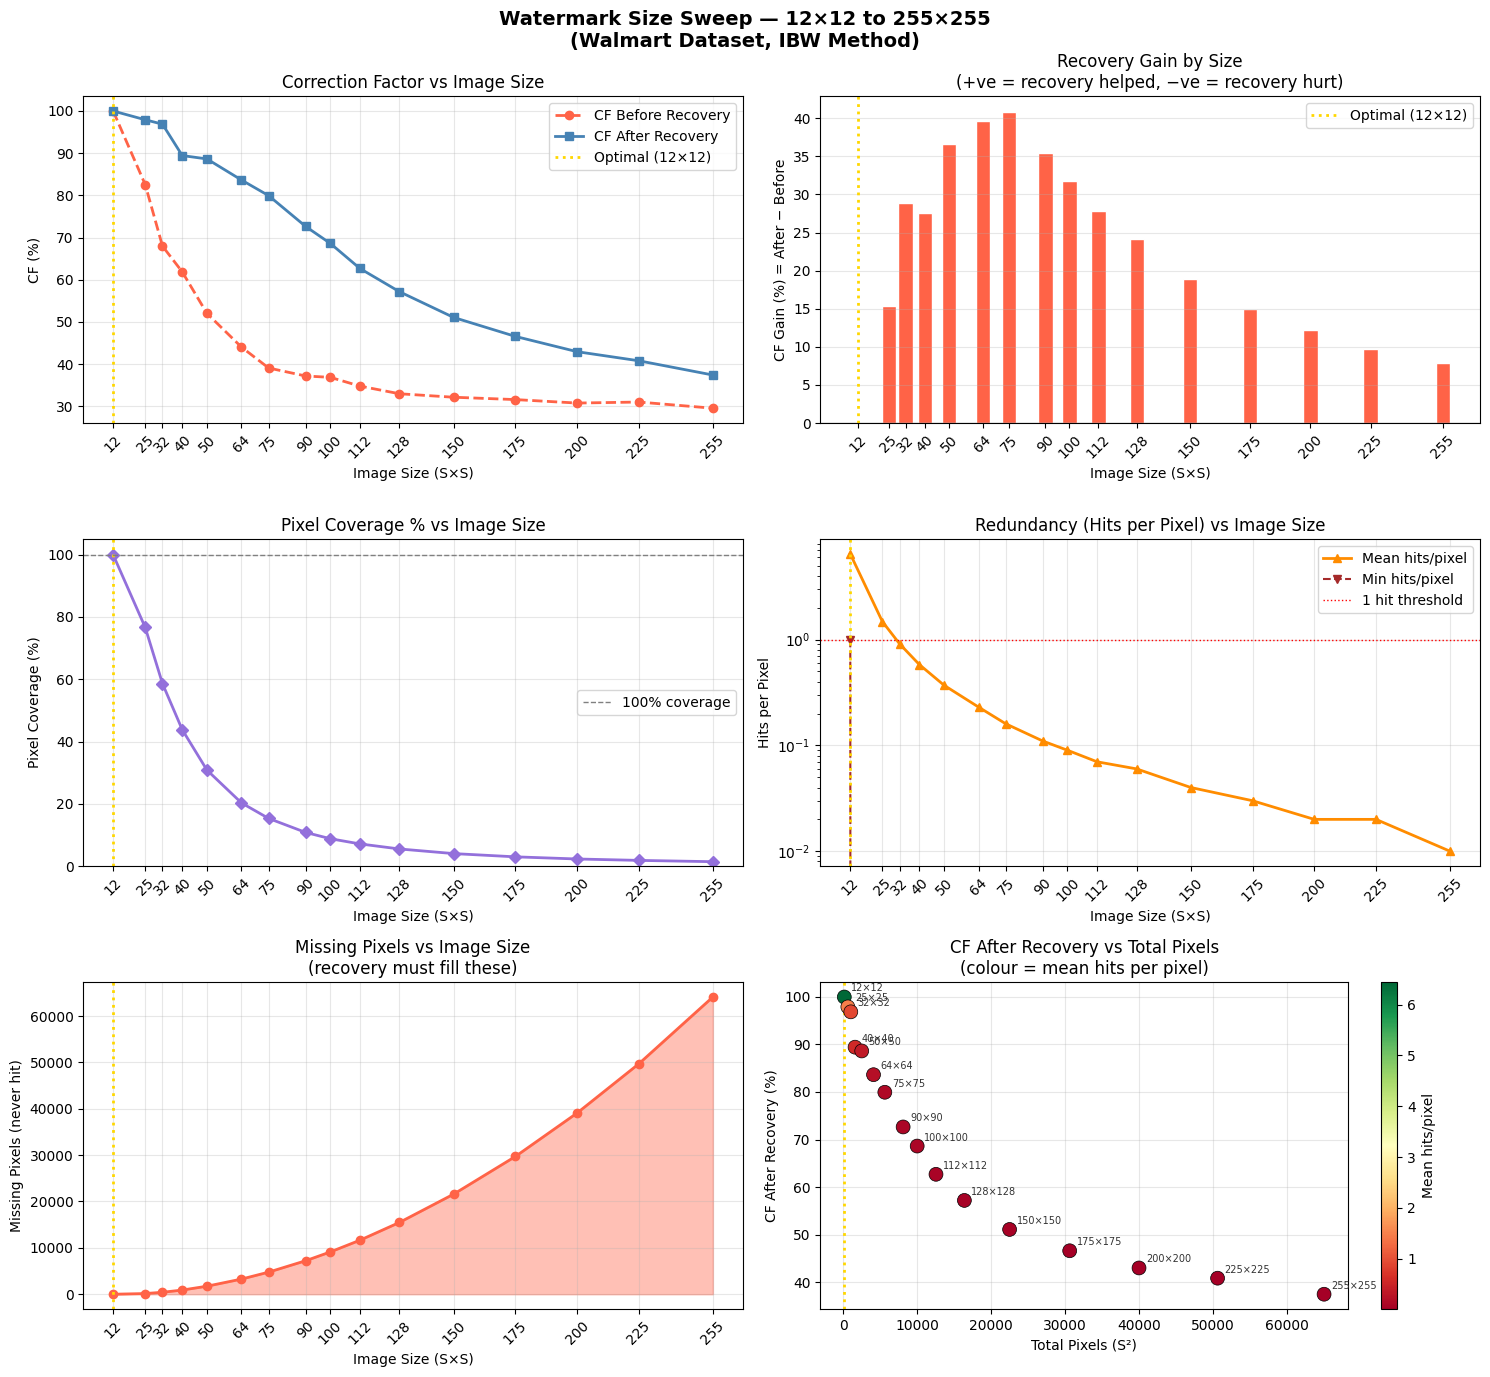

✅ sweep_analysis.png saved


In [9]:
# ── CELL 7 — Sweep Visualisations ────────────────────────

sizes  = sweep_df['size'].values
pixels = sweep_df['total_pixels'].values

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
fig.suptitle('Watermark Size Sweep — 12×12 to 255×255\n(Walmart Dataset, IBW Method)',
             fontsize=14, fontweight='bold')

# ── Plot 1: CF before and after recovery vs size ──────────
ax = axes[0, 0]
ax.plot(sizes, sweep_df['cf_before'], 'o--', color='tomato',    label='CF Before Recovery', lw=2)
ax.plot(sizes, sweep_df['cf_after'],  's-',  color='steelblue', label='CF After Recovery',  lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2, label=f'Optimal ({BEST_SIZE}×{BEST_SIZE})')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('CF (%)')
ax.set_title('Correction Factor vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 2: CF gain (after − before) vs size ─────────────
ax = axes[0, 1]
colors = ['tomato' if g > 0 else 'steelblue' for g in sweep_df['cf_gain']]
bars   = ax.bar(sizes, sweep_df['cf_gain'], color=colors, edgecolor='white', width=6)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2, label=f'Optimal ({BEST_SIZE}×{BEST_SIZE})')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('CF Gain (%) = After − Before')
ax.set_title('Recovery Gain by Size\n(+ve = recovery helped, −ve = recovery hurt)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 3: Pixel coverage % vs size ─────────────────────
ax = axes[1, 0]
ax.plot(sizes, sweep_df['coverage_pct'], 'D-', color='mediumpurple', lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.axhline(100, color='gray', linestyle='--', lw=1, label='100% coverage')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Pixel Coverage (%)')
ax.set_title('Pixel Coverage % vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 105)

# ── Plot 4: Mean hits per pixel vs size ──────────────────
ax = axes[1, 1]
ax.plot(sizes, sweep_df['mean_hits'], '^-', color='darkorange', lw=2, label='Mean hits/pixel')
ax.plot(sizes, sweep_df['min_hits'],  'v--', color='brown',     lw=1.5, label='Min hits/pixel')
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.axhline(1, color='red', linestyle=':', lw=1, label='1 hit threshold')
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Hits per Pixel')
ax.set_title('Redundancy (Hits per Pixel) vs Image Size')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')

# ── Plot 5: Missing pixels vs size ───────────────────────
ax = axes[2, 0]
ax.fill_between(sizes, sweep_df['pixels_miss'], alpha=0.4, color='tomato')
ax.plot(sizes, sweep_df['pixels_miss'], 'o-', color='tomato', lw=2)
ax.axvline(BEST_SIZE, color='gold', linestyle=':', lw=2)
ax.set_xlabel('Image Size (S×S)'); ax.set_ylabel('Missing Pixels (never hit)')
ax.set_title('Missing Pixels vs Image Size\n(recovery must fill these)')
ax.grid(True, alpha=0.3)
ax.set_xticks(sizes); ax.tick_params(axis='x', rotation=45)

# ── Plot 6: CF after recovery vs total pixels (scatter) ──
ax = axes[2, 1]
sc = ax.scatter(pixels, sweep_df['cf_after'],
                c=sweep_df['mean_hits'], cmap='RdYlGn',
                s=100, edgecolors='black', linewidths=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Mean hits/pixel')
for _, r in sweep_df.iterrows():
    ax.annotate(f"{int(r['size'])}×{int(r['size'])}",
                (r['total_pixels'], r['cf_after']),
                textcoords='offset points', xytext=(5, 4), fontsize=7, color='#333')
ax.axvline(BEST_SIZE**2, color='gold', linestyle=':', lw=2)
ax.set_xlabel('Total Pixels (S²)'); ax.set_ylabel('CF After Recovery (%)')
ax.set_title('CF After Recovery vs Total Pixels\n(colour = mean hits per pixel)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sweep_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ sweep_analysis.png saved")

🖼️  Generating visual grid of all extracted watermarks...


Rendering:   0%|          | 0/16 [00:00<?, ?it/s]

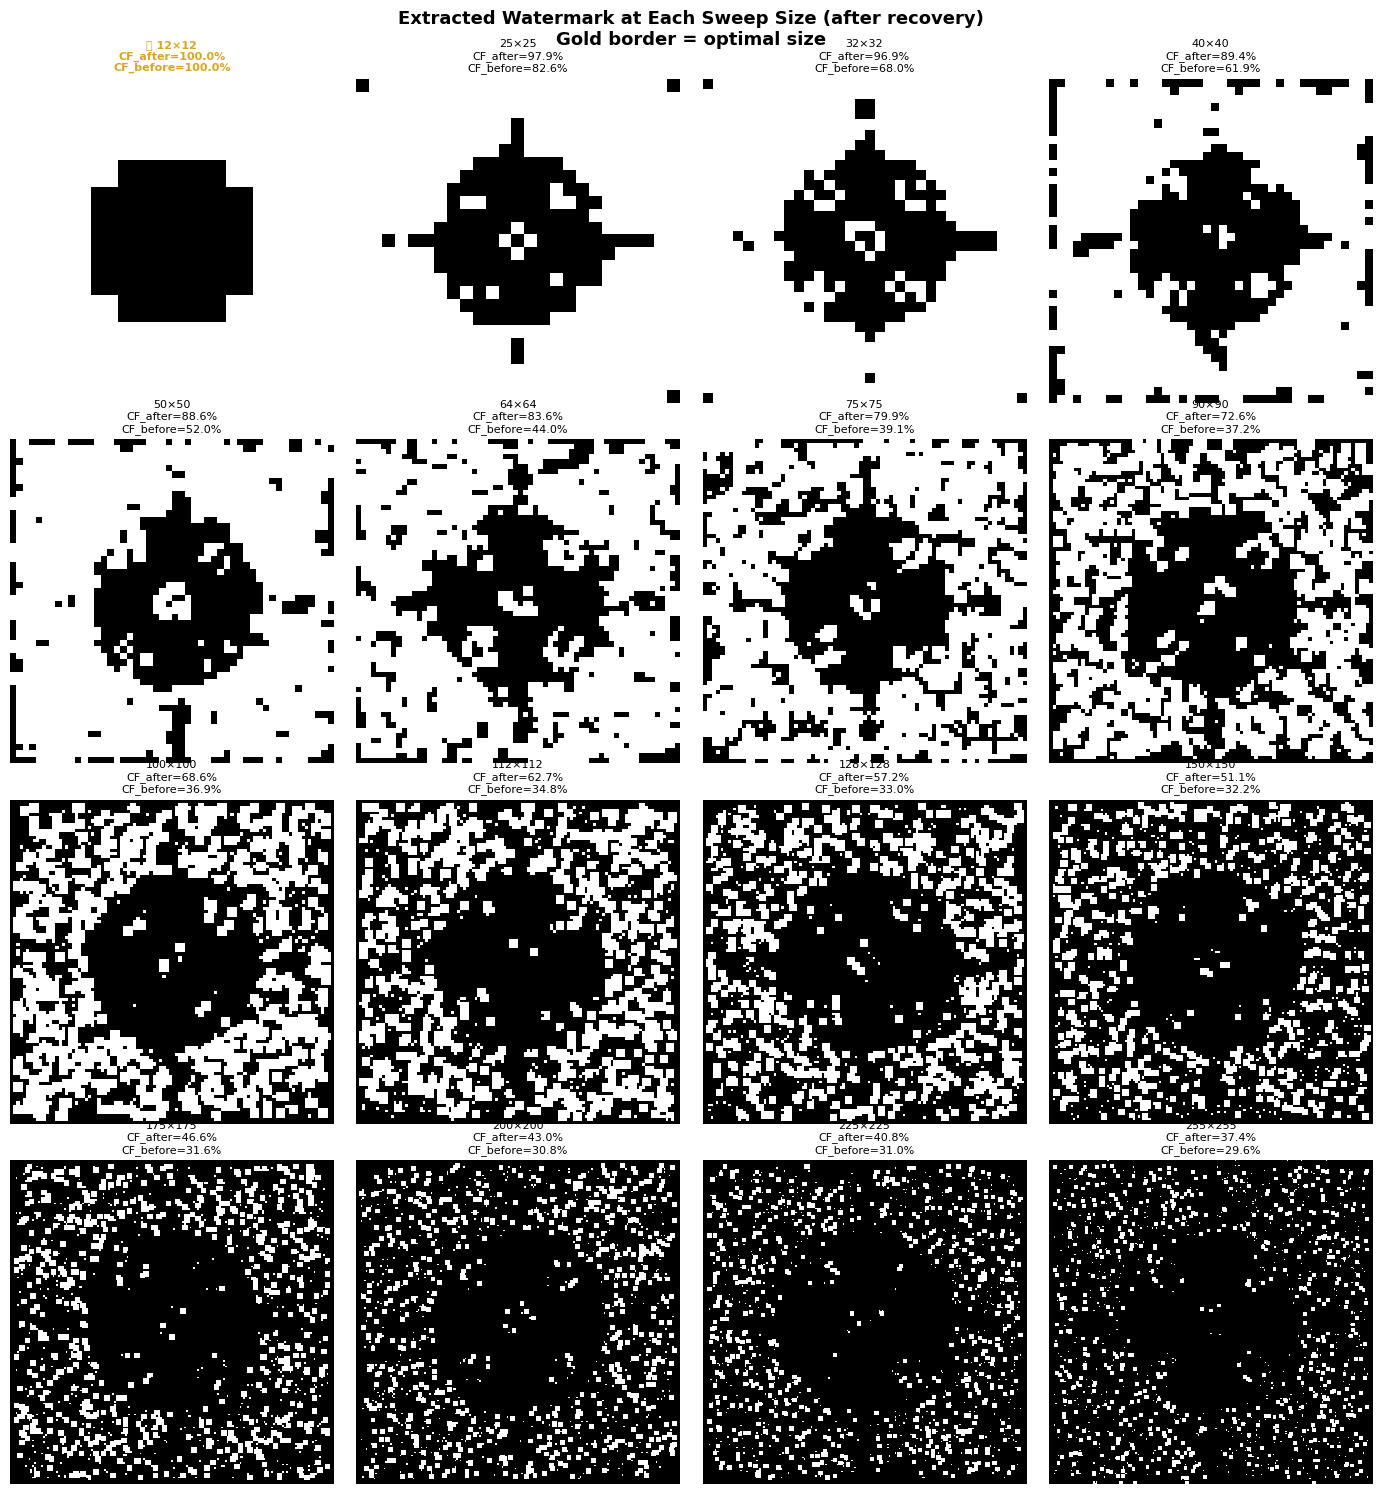

✅ sweep_visual_grid.png saved


In [10]:
# ── CELL 8 — Visual Grid: Extracted Watermarks at Every Size
# Shows what the recovered image actually LOOKS LIKE at each size
# ─────────────────────────────────────────────────────────

n    = len(SWEEP_SIZES)
ncol = 4
nrow = math.ceil(n / ncol)

fig, axes = plt.subplots(nrow, ncol, figsize=(ncol*3.5, nrow*3.8))
axes_flat = axes.flatten()

print("🖼️  Generating visual grid of all extracted watermarks...")

for i, S in enumerate(tqdm(SWEEP_SIZES, desc="Rendering")):
    img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
    wm_matrix   = (np.array(img_resized) > 127).astype(np.uint8)

    df_wm, pixel_hit_s, _  = embed_fast(wm_matrix, S, S)
    ext_raw, hit_counts_s  = extract_fast(df_wm, S, S)
    ext_recovered          = recover_image(ext_raw, hit_counts_s)

    cf_b = correction_factor(wm_matrix, ext_raw)
    cf_a = correction_factor(wm_matrix, ext_recovered)

    ax = axes_flat[i]
    ax.imshow(ext_recovered, cmap='gray', vmin=0, vmax=1, interpolation='nearest')

    is_best  = (S == BEST_SIZE)
    border_c = 'gold' if is_best else 'none'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_c)
        spine.set_linewidth(4 if is_best else 1)

    title_str  = f"{'🏆 ' if is_best else ''}{S}×{S}"
    subtitle   = f"CF_after={cf_a:.1f}%\nCF_before={cf_b:.1f}%"
    ax.set_title(f"{title_str}\n{subtitle}", fontsize=8,
                 color='goldenrod' if is_best else 'black', fontweight='bold' if is_best else 'normal')
    ax.axis('off')

# Hide empty subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

fig.suptitle('Extracted Watermark at Each Sweep Size (after recovery)\nGold border = optimal size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sweep_visual_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ sweep_visual_grid.png saved")

In [11]:
# ── CELL 9 — Summary Table ────────────────────────────────

display_df = sweep_df[[
    'size','total_pixels','coverage_pct','mean_hits','min_hits',
    'pixels_miss','cf_before','cf_after','cf_gain'
]].copy()
display_df.columns = [
    'Size','Total Pixels','Coverage %','Mean Hits','Min Hits',
    'Missing Px','CF Before %','CF After %','Gain %'
]

def highlight_best(row):
    if row['Size'] == BEST_SIZE:
        return ['background-color: #fff3cd; font-weight: bold'] * len(row)
    elif row['CF After %'] >= 99:
        return ['background-color: #d4edda'] * len(row)
    elif row['CF After %'] < 80:
        return ['background-color: #f8d7da'] * len(row)
    return [''] * len(row)

styled = display_df.style.apply(highlight_best, axis=1).format({
    'Coverage %' : '{:.2f}%',
    'Mean Hits'  : '{:.2f}',
    'CF Before %': '{:.4f}%',
    'CF After %' : '{:.4f}%',
    'Gain %'     : '{:+.4f}%',
})
display(styled)

# Interpretation guide
print("\n🟨 Gold row     = optimal size (max CF after recovery)")
print("🟩 Green rows   = CF after ≥ 99%  (excellent)")
print("🟥 Red rows     = CF after < 80%  (poor — too large for dataset)")
print()

# Key insight printout
safe_sizes   = sweep_df[sweep_df['coverage_pct'] == 100.0]
unsafe_sizes = sweep_df[sweep_df['coverage_pct'] < 100.0]
print(f"✅ Sizes with 100% pixel coverage : {safe_sizes['size'].tolist()}")
print(f"⚠️  Sizes with <100% coverage     : {unsafe_sizes['size'].tolist()}")
print(f"\n   At {BEST_SIZE}×{BEST_SIZE} (optimal):")
print(f"   → Every pixel gets ≥ {int(best_row['min_hits'])} vote(s)")
print(f"   → Mean votes per pixel: {best_row['mean_hits']:.1f}")
print(f"   → Missing pixels (need recovery): {int(best_row['pixels_miss'])}")

,Size,Total Pixels,Coverage %,Mean Hits,Min Hits,Missing Px,CF Before %,CF After %,Gain %
0,12,144,100.00%,6.44,1,0,100.0000%,100.0000%,+0.0000%
1,25,625,76.64%,1.48,0,146,82.5600%,97.9200%,+15.3600%
2,32,1024,58.59%,0.91,0,424,67.9688%,96.8750%,+28.9062%
3,40,1600,43.81%,0.58,0,899,61.8750%,89.4375%,+27.5625%
4,50,2500,30.84%,0.37,0,1729,52.0400%,88.6400%,+36.6000%
5,64,4096,20.29%,0.23,0,3265,44.0430%,83.6426%,+39.5996%
6,75,5625,15.31%,0.16,0,4764,39.0933%,79.9467%,+40.8533%
7,90,8100,10.81%,0.11,0,7224,37.1975%,72.6420%,+35.4444%
8,100,10000,8.79%,0.09,0,9121,36.8800%,68.6200%,+31.7400%
9,112,12544,7.12%,0.07,0,11651,34.8055%,62.6754%,+27.8699%



🟨 Gold row     = optimal size (max CF after recovery)
🟩 Green rows   = CF after ≥ 99%  (excellent)
🟥 Red rows     = CF after < 80%  (poor — too large for dataset)

✅ Sizes with 100% pixel coverage : [12]
⚠️  Sizes with <100% coverage     : [25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

   At 12×12 (optimal):
   → Every pixel gets ≥ 1 vote(s)
   → Mean votes per pixel: 6.4
   → Missing pixels (need recovery): 0


🏆 Running full pipeline at optimal size: 12×12

  Marked rows         : 815
  Pixel coverage      : 143/144 (99.3%)
  Mean hits/pixel     : 5.66
  CF before recovery  : 99.3056%
  CF after  recovery  : 100.0000%

  Attack % |    CF Before |    CF After
----------------------------------------
         0% |     99.3056% |   100.0000%
        10% |     99.3056% |   100.0000%
        20% |     99.3056% |   100.0000%
        30% |     97.9167% |    98.6111%
        40% |     98.6111% |    99.3056%
        50% |     98.6111% |    99.3056%
        60% |     97.9167% |    98.6111%
        70% |     98.6111% |    99.3056%
        80% |     97.9167% |    98.6111%
        90% |     96.5278% |    97.2222%


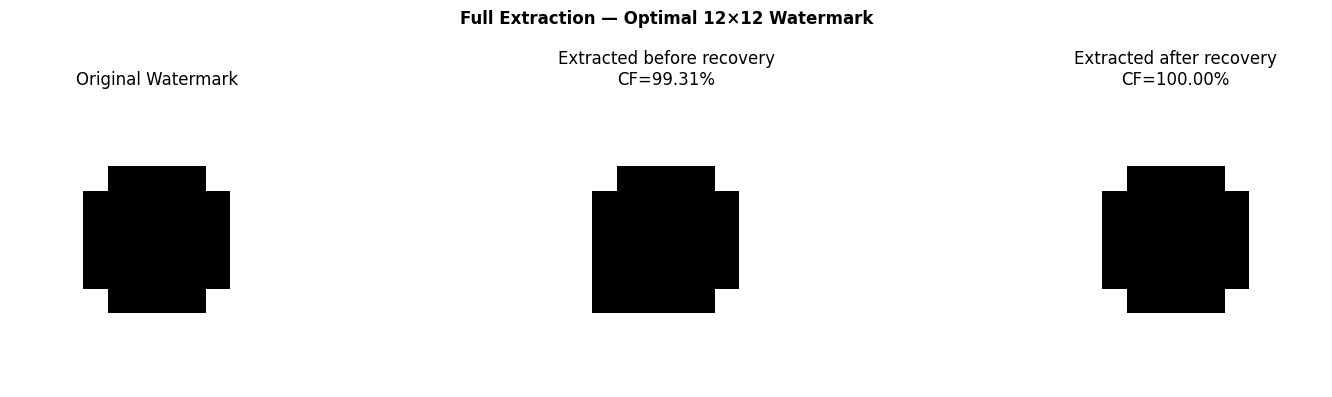

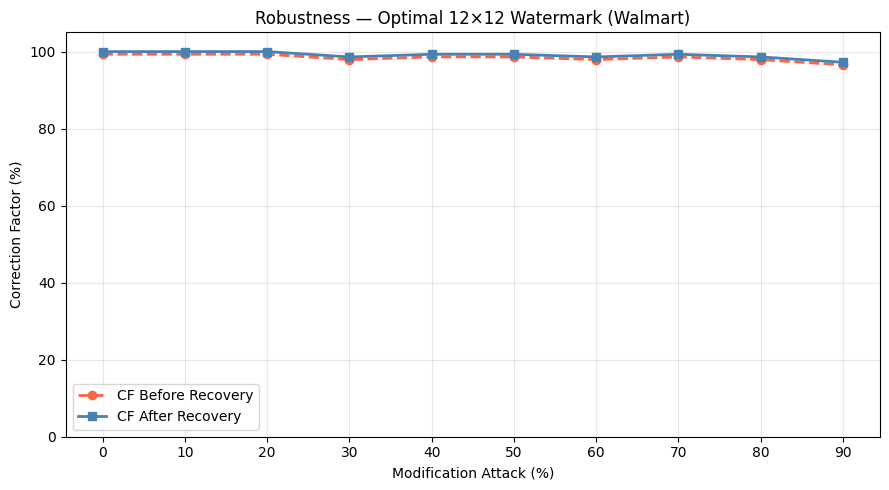

✅ All optimal-size outputs saved


In [ ]:
# ── CELL 10 — Full Pipeline at Optimal Size ───────────────
# Re-run embed + extract + attack simulation at BEST_SIZE

print(f"🏆 Running full pipeline at optimal size: {BEST_SIZE}×{BEST_SIZE}\n")

# Build final watermark matrix at best size
img_best   = IMG_PIL_ORIG.resize((BEST_SIZE, BEST_SIZE), Image.LANCZOS)
WM_BEST    = (np.array(img_best) > 127).astype(np.uint8)
IMG_H, IMG_W = BEST_SIZE, BEST_SIZE
TOTAL_PX   = BEST_SIZE * BEST_SIZE

# Embed
df_wm_best, pixel_hit_best, marked_best = embed_fast(WM_BEST, IMG_H, IMG_W)
df_wm_best.to_csv('watermarked_walmart.csv', index=False)

# Extract
ext_raw_best, hits_best = extract_fast(df_wm_best, IMG_H, IMG_W)
ext_rec_best            = recover_image(ext_raw_best, hits_best)
cf_b_best               = correction_factor(WM_BEST, ext_raw_best)
cf_a_best               = correction_factor(WM_BEST, ext_rec_best)

Image.fromarray((ext_rec_best * 255).astype(np.uint8)).save('extracted_watermark_optimal.png')

print(f"  Marked rows         : {marked_best}")
print(f"  Pixel coverage      : {(hits_best>0).sum()}/{TOTAL_PX} ({100*(hits_best>0).sum()/TOTAL_PX:.1f}%)")
print(f"  Mean hits/pixel     : {pixel_hit_best.mean():.2f}")
print(f"  CF before recovery  : {cf_b_best:.4f}%")
print(f"  CF after  recovery  : {cf_a_best:.4f}%")

# Attack simulation at optimal size
def simulate_attack(df_wm, attack_pct, seed=42):
    rng = np.random.default_rng(seed)
    df_att   = df_wm.copy()
    n_attack = int(len(df_att) * attack_pct / 100.0)
    att_rows = rng.choice(len(df_att), size=n_attack, replace=False)
    for ri in att_rows:
        col = rng.choice(NUMERIC_COLS)
        bp  = int(rng.integers(1, NUM_LSB + 1))
        if col == 'Sales':
            v = int(round(float(df_att.iloc[ri]['Sales']) * SALES_SCALE))
            if v > 0:
                df_att.iloc[ri, df_att.columns.get_loc('Sales')] = round((v ^ (1 << (bp-1))) / SALES_SCALE, 2)
        else:
            v = int(df_att.iloc[ri]['Order Quantity'])
            if v > 0:
                df_att.iloc[ri, df_att.columns.get_loc('Order Quantity')] = v ^ (1 << (bp-1))
    return df_att

attack_levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
cf_results    = []

print(f"\n{'Attack %':>10} | {'CF Before':>12} | {'CF After':>11}")
print("-" * 40)
for pct in attack_levels:
    df_att   = df_wm_best.copy() if pct == 0 else simulate_attack(df_wm_best, pct)
    e_r, h_c = extract_fast(df_att, IMG_H, IMG_W)
    e_rec    = recover_image(e_r, h_c)
    cb, ca   = correction_factor(WM_BEST, e_r), correction_factor(WM_BEST, e_rec)
    cf_results.append({'Attack %': pct, 'CF Before': cb, 'CF After': ca})
    print(f"{pct:>10}% | {cb:>11.4f}% | {ca:>10.4f}%")

cf_df = pd.DataFrame(cf_results)
cf_df.to_csv('attack_cf_results_optimal.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, mat, title in zip(axes,
    [WM_BEST, ext_raw_best, ext_rec_best],
    ['Original Watermark', f'Extracted before recovery\nCF={cf_b_best:.2f}%',
     f'Extracted after recovery\nCF={cf_a_best:.2f}%']):
    ax.imshow(mat, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
plt.suptitle(f'Full Extraction — Optimal {BEST_SIZE}×{BEST_SIZE} Watermark', fontweight='bold')
plt.tight_layout()
plt.savefig('extraction_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(cf_df['Attack %'], cf_df['CF Before'], 'o--', color='tomato',    label='CF Before Recovery', lw=2)
plt.plot(cf_df['Attack %'], cf_df['CF After'],  's-',  color='steelblue', label='CF After Recovery',  lw=2)
plt.xlabel('Modification Attack (%)'); plt.ylabel('Correction Factor (%)')
plt.title(f'Robustness — Optimal {BEST_SIZE}×{BEST_SIZE} Watermark (Walmart)')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(attack_levels); plt.ylim(0, 105)
plt.tight_layout()
plt.savefig('attack_robustness_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All optimal-size outputs saved")

🏆 Running full pipeline at optimal size: 12×12

  Marked rows         : 927
  Pixel coverage      : 144/144 (100.0%)
  Mean hits/pixel     : 6.44
  CF before recovery  : 100.0000%
  CF after  recovery  : 100.0000%

  Attack % |    CF Before |    CF After
----------------------------------------
         0% |    100.0000% |   100.0000%
🔧 Attack changed 938 values out of 984 selected rows
        10% |    100.0000% |   100.0000%
🔧 Attack changed 1888 values out of 1968 selected rows
        20% |     97.2222% |    97.2222%
🔧 Attack changed 2814 values out of 2952 selected rows
        30% |     88.1944% |    88.1944%
🔧 Attack changed 3724 values out of 3936 selected rows
        40% |     80.5556% |    80.5556%
🔧 Attack changed 4694 values out of 4920 selected rows
        50% |     48.6111% |    48.6111%
🔧 Attack changed 5614 values out of 5904 selected rows
        60% |     37.5000% |    37.5000%
🔧 Attack changed 6576 values out of 6888 selected rows
        70% |     17.3611% |    17

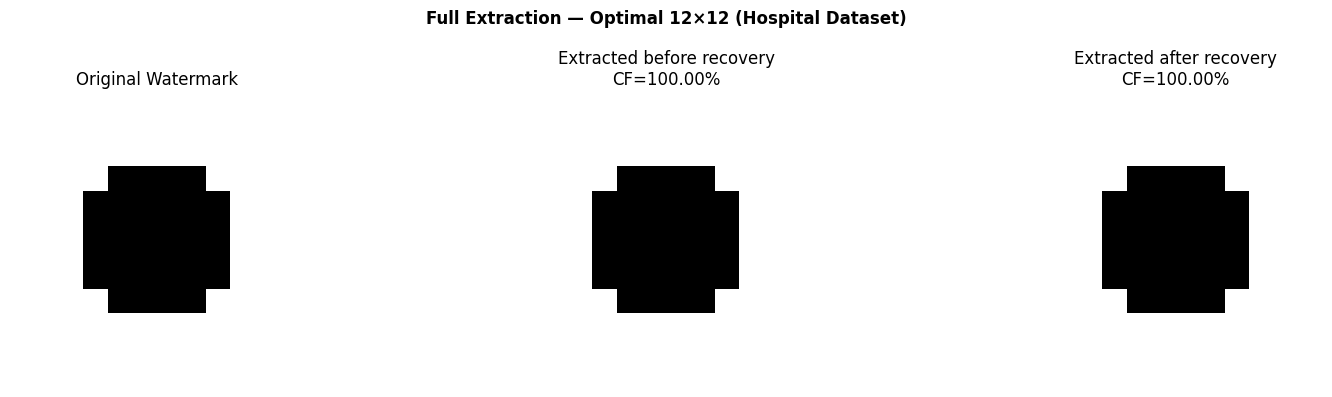

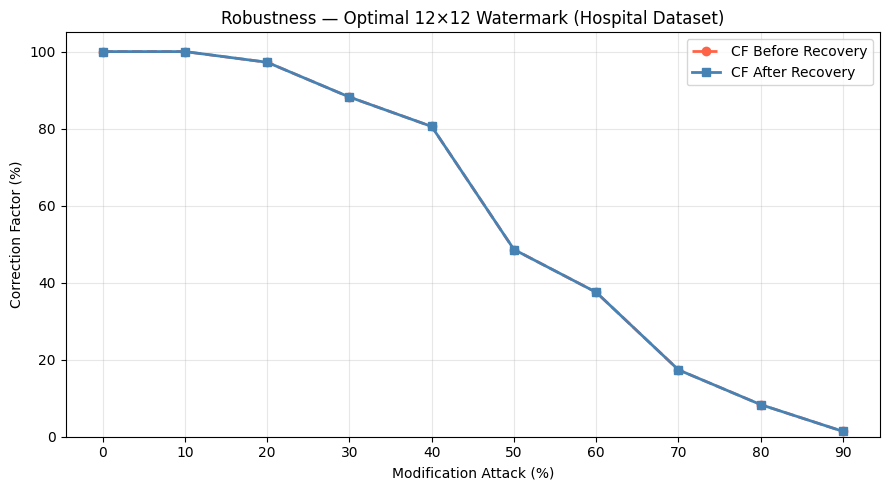

✅ All optimal-size outputs saved (Hospital dataset)


In [13]:
# ── CELL 10 — Full Pipeline at Optimal Size (Hospital Dataset) ───────────────

print(f"🏆 Running full pipeline at optimal size: {BEST_SIZE}×{BEST_SIZE}\n")

# ── Build watermark ─────────────────────────────────────
img_best   = IMG_PIL_ORIG.resize((BEST_SIZE, BEST_SIZE), Image.LANCZOS)
WM_BEST    = (np.array(img_best) > 127).astype(np.uint8)
IMG_H, IMG_W = BEST_SIZE, BEST_SIZE
TOTAL_PX   = BEST_SIZE * BEST_SIZE

# ── Embed ───────────────────────────────────────────────
df_wm_best, pixel_hit_best, marked_best = embed_fast(WM_BEST, IMG_H, IMG_W)
df_wm_best.to_csv('watermarked_hospital.csv', index=False)

# ── Extract ─────────────────────────────────────────────
ext_raw_best, hits_best = extract_fast(df_wm_best, IMG_H, IMG_W)
ext_rec_best            = recover_image(ext_raw_best, hits_best)

cf_b_best = correction_factor(WM_BEST, ext_raw_best)
cf_a_best = correction_factor(WM_BEST, ext_rec_best)

Image.fromarray((ext_rec_best * 255).astype(np.uint8)).save('extracted_watermark_optimal.png')

print(f"  Marked rows         : {marked_best}")
print(f"  Pixel coverage      : {(hits_best>0).sum()}/{TOTAL_PX} ({100*(hits_best>0).sum()/TOTAL_PX:.1f}%)")
print(f"  Mean hits/pixel     : {pixel_hit_best.mean():.2f}")
print(f"  CF before recovery  : {cf_b_best:.4f}%")
print(f"  CF after  recovery  : {cf_a_best:.4f}%")


# ── Attack simulation (FIXED for hospital measures) ─────
# def simulate_attack(df_wm, attack_pct, seed=42):
#     rng = np.random.default_rng(seed)
#     df_att   = df_wm.copy()

#     n_attack = int(len(df_att) * attack_pct / 100.0)
#     att_rows = rng.choice(len(df_att), size=n_attack, replace=False)

#     for ri in att_rows:
#         col = rng.choice(MEASURE_COLS)
#         bp  = int(rng.integers(1, NUM_LSB + 1))

#         scale = MEASURE_SCALE[col]
#         val = float(df_att.iloc[ri][col])

#         v = int(round(val * scale))

#         if v > 0:
#             new_v = v ^ (1 << (bp - 1))

#             if scale == 1:
#                 df_att.iloc[ri, df_att.columns.get_loc(col)] = int(new_v)
#             else:
#                 df_att.iloc[ri, df_att.columns.get_loc(col)] = round(
#                     new_v / scale, 3 if scale == 1000 else 2
#                 )

#     return df_att

def simulate_attack(df_wm, attack_pct, seed=42):
    rng = np.random.default_rng(seed)
    df_att = df_wm.copy()

    n_attack = int(len(df_att) * attack_pct / 100.0)
    att_rows = rng.choice(len(df_att), size=n_attack, replace=False)

    changed = 0

    for ri in att_rows:
        pk = int(df_att.iloc[ri]['pk'])
        vpk = VPK_TABLE[pk]

        # Attack the actual measure used by the watermark for this row
        col = MEASURE_COLS[vpk % NUM_A]
        bp  = (vpk % NUM_LSB) + 1   # attack the marked bit position

        scale = MEASURE_SCALE[col]
        val = float(df_att.iloc[ri][col])
        v = int(round(val * scale))

        if v > 0:
            new_v = v ^ (1 << (bp - 1))
            changed += int(new_v != v)

            if scale == 1:
                df_att.iloc[ri, df_att.columns.get_loc(col)] = int(new_v)
            else:
                df_att.iloc[ri, df_att.columns.get_loc(col)] = round(
                    new_v / scale, 3 if scale == 1000 else 2
                )

    print(f"🔧 Attack changed {changed} values out of {n_attack} selected rows")
    return df_att


# ── Run attacks ─────────────────────────────────────────
attack_levels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
cf_results    = []

print(f"\n{'Attack %':>10} | {'CF Before':>12} | {'CF After':>11}")
print("-" * 40)

for pct in attack_levels:
    df_att   = df_wm_best.copy() if pct == 0 else simulate_attack(df_wm_best, pct)

    e_r, h_c = extract_fast(df_att, IMG_H, IMG_W)
    e_rec    = recover_image(e_r, h_c)

    cb = correction_factor(WM_BEST, e_r)
    ca = correction_factor(WM_BEST, e_rec)

    cf_results.append({'Attack %': pct, 'CF Before': cb, 'CF After': ca})

    print(f"{pct:>10}% | {cb:>11.4f}% | {ca:>10.4f}%")


# ── Save results ────────────────────────────────────────
cf_df = pd.DataFrame(cf_results)
cf_df.to_csv('attack_cf_results_hospital.csv', index=False)


# ── Visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mat, title in zip(
    axes,
    [WM_BEST, ext_raw_best, ext_rec_best],
    [
        'Original Watermark',
        f'Extracted before recovery\nCF={cf_b_best:.2f}%',
        f'Extracted after recovery\nCF={cf_a_best:.2f}%'
    ]
):
    ax.imshow(mat, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(f'Full Extraction — Optimal {BEST_SIZE}×{BEST_SIZE} (Hospital Dataset)', fontweight='bold')
plt.tight_layout()
plt.savefig('extraction_optimal.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Robustness plot ─────────────────────────────────────
plt.figure(figsize=(9, 5))

plt.plot(cf_df['Attack %'], cf_df['CF Before'],
         'o--', color='tomato', label='CF Before Recovery', lw=2)

plt.plot(cf_df['Attack %'], cf_df['CF After'],
         's-', color='steelblue', label='CF After Recovery', lw=2)

plt.xlabel('Modification Attack (%)')
plt.ylabel('Correction Factor (%)')
plt.title(f'Robustness — Optimal {BEST_SIZE}×{BEST_SIZE} Watermark (Hospital Dataset)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(attack_levels)
plt.ylim(0, 105)

plt.tight_layout()
plt.savefig('attack_robustness_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ All optimal-size outputs saved (Hospital dataset)")

In [ ]:
# !pip install scikit-image --quiet

,Operation,Rows in view,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Status
0,Roll-up,274,13.89,25.6944,47.9167,-0.006333,0.037130,Poor / heavily degraded
1,Drill-down,9841,100.00,100.0000,100.0000,1.000000,1.000000,Perfect / clear
2,Slice,6230,99.31,99.3056,100.0000,0.985846,1.000000,Perfect / clear
3,Dice,1047,55.56,64.5833,96.5278,0.514274,0.877244,Good / recognizable


✅ olap_results_hospital.csv saved


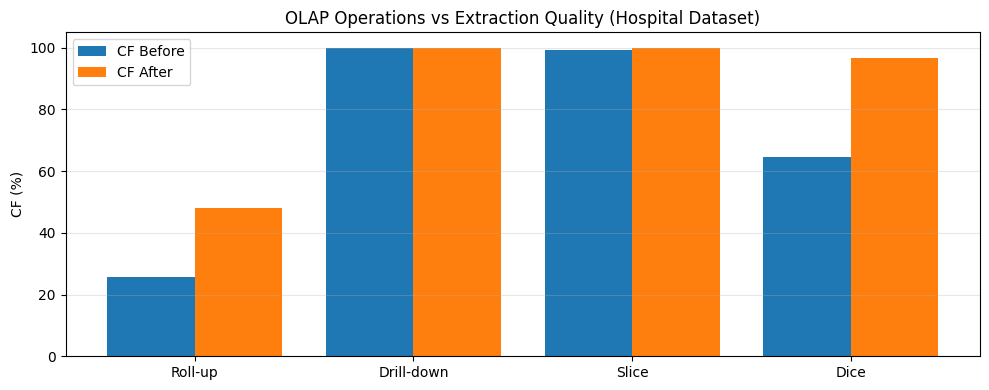

✅ Saved:
   Roll-up_extracted_raw.png
   Roll-up_extracted_recovered.png
   Drill-down_extracted_raw.png
   Drill-down_extracted_recovered.png
   Slice_extracted_raw.png
   Slice_extracted_recovered.png
   Dice_extracted_raw.png
   Dice_extracted_recovered.png
   olap_cf_summary_hospital.png


In [14]:
# ── CELL 10A — OLAP operations for Hospital Dataset ─────────────

from skimage.metrics import structural_similarity as skimage_ssim

# ---- SSIM for binary watermark matrices ----
def binary_ssim(orig, extracted):
    return float(
        skimage_ssim(
            orig.astype(np.float32),
            extracted.astype(np.float32),
            data_range=1.0
        )
    )

# ---- Save a binary watermark matrix as image ----
def save_binary_matrix_image(matrix, filename, scale=40):
    matrix = matrix.astype(np.uint8)
    img = Image.fromarray((1 - matrix) * 255)  # 1=black, 0=white
    img = img.resize((matrix.shape[1] * scale, matrix.shape[0] * scale), Image.NEAREST)
    img.save(filename)

# ---- Extract watermark from ANY view/table that still has the relevant columns ----
def extract_from_view(df_view, img_h, img_w):
    """
    Works on:
    - slice / dice / drill-down views (subset of original tuples)
    - roll-up views (aggregated table; watermark will usually degrade)

    The view should contain at least:
    pk, and the hospital measure columns.
    """
    view = df_view.copy()

    if 'pk' not in view.columns:
        view = view.reset_index(drop=True)
        view.insert(0, 'pk', range(1, len(view) + 1))

    view = view.set_index('pk', drop=False)

    ones = np.zeros((img_h, img_w), dtype=np.int32)
    total = np.zeros((img_h, img_w), dtype=np.int32)

    for pk, row in view.iterrows():
        pk = int(pk)
        vpk = compute_vpk(pk, SECRET_KEY)

        if vpk % F != 0:
            continue

        attr_name = MEASURE_COLS[vpk % NUM_A]
        bit_pos   = (vpk % NUM_LSB) + 1

        scale = MEASURE_SCALE[attr_name]
        raw_val = int(round(float(row[attr_name]) * scale))

        if not value_tolerable(raw_val, NUM_LSB):
            continue

        h, w = compute_pixel_coord(vpk, img_h, img_w)
        ext_lsb = get_lsb(raw_val, bit_pos)
        msb_bit = select_msb_bit(vpk, raw_val, NUM_MSB)

        ones[h, w] += (ext_lsb ^ msb_bit)
        total[h, w] += 1

    ext = np.zeros((img_h, img_w), dtype=np.uint8)
    mask = total > 0
    ext[mask] = (ones[mask] >= (total[mask] / 2.0)).astype(np.uint8)
    return ext, total

# ---- Status label from CF/SSIM ----
def image_status(cf_after, ssim_after):
    if cf_after >= 99 and ssim_after >= 0.98:
        return "Perfect / clear"
    elif cf_after >= 95 and ssim_after >= 0.90:
        return "Excellent / clear"
    elif cf_after >= 85 and ssim_after >= 0.75:
        return "Good / recognizable"
    elif cf_after >= 70 and ssim_after >= 0.50:
        return "Moderate / noisy"
    else:
        return "Poor / heavily degraded"

# ---- OLAP view builders ----
BASE = df_wm_best.copy()
BASE['DOA'] = pd.to_datetime(BASE['DOA'], errors='coerce')
BASE['Month'] = BASE['DOA'].dt.to_period('M').astype(str)

def first_non_null(series, fallback):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else fallback

# Stable defaults from the dataset
DEFAULT_GENDER = first_non_null(BASE['GENDER'], 'Unknown')
DEFAULT_RURAL = first_non_null(BASE['RURAL'], 'Unknown')
DEFAULT_ADMISSION_TYPE = first_non_null(BASE['ADMISSION_TYPE'], 'Unknown')
DEFAULT_MONTH = BASE['Month'][BASE['Month'] != 'NaT'].iloc[0] if (BASE['Month'] != 'NaT').any() else 'Unknown'

# 1) Roll-up: aggregate to a higher level of detail
def make_rollup_view(df):
    d = df.copy()
    d['DOA'] = pd.to_datetime(d['DOA'], errors='coerce')
    d['Month'] = d['DOA'].dt.to_period('M').astype(str)

    rolled = (
        d.groupby(['GENDER', 'RURAL', 'ADMISSION_TYPE', 'Month'], as_index=False)
         .agg({
             'DURATION_OF_STAY': 'mean',
             'ICU_STAY': 'mean',
             'HB': 'mean',
             'CREATININE': 'mean'
         })
    )

    rolled.insert(0, 'pk', range(1, len(rolled) + 1))
    rolled['DOA'] = pd.to_datetime(rolled['Month'] + '-01', errors='coerce')

    return rolled[['pk', 'DOA', 'GENDER', 'RURAL', 'ADMISSION_TYPE',
                   'DURATION_OF_STAY', 'ICU_STAY', 'HB', 'CREATININE']]

# 2) Drill-down: finest detail view (original detailed tuples)
def make_drilldown_view(df):
    return df.copy()

# 3) Slice: one dimension fixed
def make_slice_view(df, gender=DEFAULT_GENDER):
    return df[df['GENDER'] == gender].copy()

# 4) Dice: multiple dimensions fixed
def make_dice_view(df, gender=DEFAULT_GENDER, rural=DEFAULT_RURAL, admission_type=DEFAULT_ADMISSION_TYPE):
    return df[
        (df['GENDER'] == gender) &
        (df['RURAL'] == rural) &
        (df['ADMISSION_TYPE'] == admission_type)
    ].copy()

# ---- Run one OLAP experiment ----
def evaluate_olap_operation(name, df_view, wm_matrix):
    raw, counts = extract_from_view(df_view, wm_matrix.shape[0], wm_matrix.shape[1])
    recovered = recover_image(raw, counts)

    cf_before = correction_factor(wm_matrix, raw)
    cf_after  = correction_factor(wm_matrix, recovered)
    ssim_before = binary_ssim(wm_matrix, raw)
    ssim_after  = binary_ssim(wm_matrix, recovered)

    status = image_status(cf_after, ssim_after)

    save_binary_matrix_image(raw, f'{name}_extracted_raw.png', scale=40)
    save_binary_matrix_image(recovered, f'{name}_extracted_recovered.png', scale=40)

    return {
        'Operation': name,
        'Rows in view': len(df_view),
        'Coverage %': round(100.0 * (counts > 0).sum() / wm_matrix.size, 2),
        'CF Before %': round(cf_before, 4),
        'CF After %': round(cf_after, 4),
        'SSIM Before': round(ssim_before, 6),
        'SSIM After': round(ssim_after, 6),
        'Status': status
    }

# ---- Build views ----
rollup_view    = make_rollup_view(BASE)
drilldown_view = make_drilldown_view(BASE)
slice_view     = make_slice_view(BASE, gender=DEFAULT_GENDER)
dice_view      = make_dice_view(BASE, gender=DEFAULT_GENDER,
                                rural=DEFAULT_RURAL,
                                admission_type=DEFAULT_ADMISSION_TYPE)

# ---- Evaluate ----
olap_results = []
olap_results.append(evaluate_olap_operation('Roll-up', rollup_view, WM_BEST))
olap_results.append(evaluate_olap_operation('Drill-down', drilldown_view, WM_BEST))
olap_results.append(evaluate_olap_operation('Slice', slice_view, WM_BEST))
olap_results.append(evaluate_olap_operation('Dice', dice_view, WM_BEST))

olap_df = pd.DataFrame(olap_results)
display(olap_df)

olap_df.to_csv('olap_results_hospital.csv', index=False)
print("✅ olap_results_hospital.csv saved")

# ---- Optional: a compact plot ----
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.arange(len(olap_df))
ax.bar(x - 0.2, olap_df['CF Before %'], width=0.4, label='CF Before')
ax.bar(x + 0.2, olap_df['CF After %'],  width=0.4, label='CF After')
ax.set_xticks(x)
ax.set_xticklabels(olap_df['Operation'])
ax.set_ylabel('CF (%)')
ax.set_title('OLAP Operations vs Extraction Quality (Hospital Dataset)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('olap_cf_summary_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved:")
print("   Roll-up_extracted_raw.png")
print("   Roll-up_extracted_recovered.png")
print("   Drill-down_extracted_raw.png")
print("   Drill-down_extracted_recovered.png")
print("   Slice_extracted_raw.png")
print("   Slice_extracted_recovered.png")
print("   Dice_extracted_raw.png")
print("   Dice_extracted_recovered.png")
print("   olap_cf_summary_hospital.png")

In [15]:
# ── CELL 10B — OLAP Size Sweep for Roll-up / Drill-down / Slice / Dice (Hospital) ───────

from skimage.metrics import structural_similarity as skimage_ssim
from IPython.display import display

def binary_ssim(orig, extracted):
    return float(
        skimage_ssim(
            orig.astype(np.float32),
            extracted.astype(np.float32),
            data_range=1.0
        )
    )

def olap_status(cf_after, ssim_after):
    if cf_after >= 99 and ssim_after >= 0.98:
        return "Perfect / clear"
    elif cf_after >= 95 and ssim_after >= 0.90:
        return "Excellent / clear"
    elif cf_after >= 85 and ssim_after >= 0.75:
        return "Good / recognizable"
    elif cf_after >= 70 and ssim_after >= 0.50:
        return "Moderate / noisy"
    else:
        return "Poor / heavily degraded"

def evaluate_operation_for_size(op_name, df_view, wm_matrix, size_tag):
    raw, counts = extract_from_view(df_view, wm_matrix.shape[0], wm_matrix.shape[1])
    recovered = recover_image(raw, counts)

    cf_before = correction_factor(wm_matrix, raw)
    cf_after  = correction_factor(wm_matrix, recovered)
    ssim_before = binary_ssim(wm_matrix, raw)
    ssim_after  = binary_ssim(wm_matrix, recovered)
    status = olap_status(cf_after, ssim_after)

    save_binary_matrix_image(raw, f'{op_name}_{size_tag}_raw.png', scale=40)
    save_binary_matrix_image(recovered, f'{op_name}_{size_tag}_recovered.png', scale=40)

    return {
        'Operation': op_name,
        'Size': size_tag,
        'Rows in View': len(df_view),
        'Coverage %': round(100.0 * (counts > 0).sum() / wm_matrix.size, 2),
        'CF Before %': round(cf_before, 4),
        'CF After %': round(cf_after, 4),
        'SSIM Before': round(ssim_before, 6),
        'SSIM After': round(ssim_after, 6),
        'Status': status
    }

def get_olap_views(base_df):
    base = base_df.copy()
    base['DOA'] = pd.to_datetime(base['DOA'], errors='coerce')
    base['Month'] = base['DOA'].dt.to_period('M').astype(str)

    default_gender = base['GENDER'].dropna().iloc[0] if base['GENDER'].dropna().shape[0] > 0 else 'Unknown'
    default_rural = base['RURAL'].dropna().iloc[0] if base['RURAL'].dropna().shape[0] > 0 else 'Unknown'
    default_admission_type = base['ADMISSION_TYPE'].dropna().iloc[0] if base['ADMISSION_TYPE'].dropna().shape[0] > 0 else 'Unknown'

    def make_rollup_view(df):
        d = df.copy()
        d['DOA'] = pd.to_datetime(d['DOA'], errors='coerce')
        d['Month'] = d['DOA'].dt.to_period('M').astype(str)

        rolled = (
            d.groupby(['GENDER', 'RURAL', 'ADMISSION_TYPE', 'Month'], as_index=False)
             .agg({
                 'DURATION_OF_STAY': 'mean',
                 'ICU_STAY': 'mean',
                 'HB': 'mean',
                 'CREATININE': 'mean'
             })
        )

        rolled.insert(0, 'pk', range(1, len(rolled) + 1))
        rolled['DOA'] = pd.to_datetime(rolled['Month'] + '-01', errors='coerce')

        return rolled[['pk', 'DOA', 'GENDER', 'RURAL', 'ADMISSION_TYPE',
                       'DURATION_OF_STAY', 'ICU_STAY', 'HB', 'CREATININE']]

    def make_drilldown_view(df):
        return df.copy()

    def make_slice_view(df):
        return df[df['GENDER'] == default_gender].copy()

    def make_dice_view(df):
        return df[
            (df['GENDER'] == default_gender) &
            (df['RURAL'] == default_rural) &
            (df['ADMISSION_TYPE'] == default_admission_type)
        ].copy()

    return {
        'Rollup': make_rollup_view(base),
        'Drilldown': make_drilldown_view(base),
        'Slice': make_slice_view(base),
        'Dice': make_dice_view(base)
    }

# Run sweep for all OLAP operations
olap_sweep_records = []

print("🔁 Running OLAP size sweep for all 4 operations...")
print(f"{'Op':>10} | {'Size':>7} | {'CF_before':>10} | {'CF_after':>9} | {'SSIM_before':>11} | {'SSIM_after':>10} | {'Status':>24}")
print("-" * 105)

views_dict = get_olap_views(df_wm_best)

for op_name, view_df in views_dict.items():
    for S in SWEEP_SIZES:
        img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
        wm_matrix = (np.array(img_resized) > 127).astype(np.uint8)

        result = evaluate_operation_for_size(op_name, view_df, wm_matrix, f"{S}x{S}")
        olap_sweep_records.append(result)

        print(f"{op_name:>10} | {str(S)+'x'+str(S):>7} | "
              f"{result['CF Before %']:>9.4f}% | {result['CF After %']:>8.4f}% | "
              f"{result['SSIM Before']:>11.6f} | {result['SSIM After']:>10.6f} | "
              f"{result['Status']:>24}")

olap_sweep_df = pd.DataFrame(olap_sweep_records)
olap_sweep_df.to_csv('olap_size_sweep_results_hospital.csv', index=False)
print("\n✅ olap_size_sweep_results_hospital.csv saved")

# ── Separate tables for each operation ────────────────────────────────────────
for op_name in ['Rollup', 'Drilldown', 'Slice', 'Dice']:
    print(f"\n==================== {op_name.upper()} ====================")
    sub = olap_sweep_df[olap_sweep_df['Operation'] == op_name].copy()

    display(
        sub[[
            'Size', 'Rows in View', 'Coverage %',
            'CF Before %', 'CF After %',
            'SSIM Before', 'SSIM After',
            'Status'
        ]].reset_index(drop=True)
    )

🔁 Running OLAP size sweep for all 4 operations...
        Op |    Size |  CF_before |  CF_after | SSIM_before | SSIM_after |                   Status
---------------------------------------------------------------------------------------------------------
    Rollup |   12x12 |   25.6944% |  47.9167% |   -0.006333 |   0.037130 |  Poor / heavily degraded
    Rollup |   25x25 |   24.4800% |  26.7200% |    0.000944 |  -0.076380 |  Poor / heavily degraded
    Rollup |   32x32 |   23.9258% |  28.2227% |    0.000927 |  -0.003504 |  Poor / heavily degraded
    Rollup |   40x40 |   32.5625% |  34.8750% |    0.002222 |  -0.015053 |  Poor / heavily degraded
    Rollup |   50x50 |   30.6000% |  32.2400% |    0.022512 |   0.013058 |  Poor / heavily degraded
    Rollup |   64x64 |   29.2480% |  30.2490% |    0.032763 |   0.016559 |  Poor / heavily degraded
    Rollup |   75x75 |   27.8400% |  29.1200% |    0.045537 |   0.037304 |  Poor / heavily degraded
    Rollup |   90x90 |   29.3704% |  30.2716

,Size,Rows in View,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Status
0,12x12,274,13.89,25.6944,47.9167,-0.006333,0.037130,Poor / heavily degraded
1,25x25,274,3.68,24.4800,26.7200,0.000944,-0.076380,Poor / heavily degraded
2,32x32,274,2.05,23.9258,28.2227,0.000927,-0.003504,Poor / heavily degraded
3,40x40,274,1.44,32.5625,34.8750,0.002222,-0.015053,Poor / heavily degraded
4,50x50,274,0.92,30.6000,32.2400,0.022512,0.013058,Poor / heavily degraded
5,64x64,274,0.56,29.2480,30.2490,0.032763,0.016559,Poor / heavily degraded
6,75x75,274,0.41,27.8400,29.1200,0.045537,0.037304,Poor / heavily degraded
7,90x90,274,0.28,29.3704,30.2716,0.070628,0.066805,Poor / heavily degraded
8,100x100,274,0.23,30.7700,31.1200,0.075853,0.065374,Poor / heavily degraded
9,112x112,274,0.18,30.0064,30.3412,0.090172,0.081177,Poor / heavily degraded



==================== DRILLDOWN ====================


,Size,Rows in View,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Status
0,12x12,9841,100.00,100.0000,100.0000,1.000000,1.000000,Perfect / clear
1,25x25,9841,76.64,60.0000,71.5200,0.036741,0.043066,Poor / heavily degraded
2,32x32,9841,58.59,48.5352,70.8008,0.007948,0.005903,Poor / heavily degraded
3,40x40,9841,43.81,45.3125,65.2500,-0.014788,0.027256,Poor / heavily degraded
4,50x50,9841,30.84,40.3200,65.8400,0.005782,0.021258,Poor / heavily degraded
5,64x64,9841,20.29,36.7676,62.2803,0.011589,0.015128,Poor / heavily degraded
6,75x75,9841,15.31,33.5289,58.4711,0.005937,0.009423,Poor / heavily degraded
7,90x90,9841,10.81,33.0617,53.2469,0.003305,-0.004219,Poor / heavily degraded
8,100x100,9841,8.79,33.2100,49.6900,0.000592,-0.005400,Poor / heavily degraded
9,112x112,9841,7.12,31.9834,46.1177,0.008933,0.002706,Poor / heavily degraded



==================== SLICE ====================


,Size,Rows in View,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Status
0,12x12,6230,99.31,99.3056,100.0000,0.985846,1.000000,Perfect / clear
1,25x25,6230,60.32,51.5200,71.3600,0.019219,0.051455,Poor / heavily degraded
2,32x32,6230,42.77,40.5273,69.0430,0.000461,-0.007745,Poor / heavily degraded
3,40x40,6230,29.94,41.6250,65.1250,-0.015014,0.041452,Poor / heavily degraded
4,50x50,6230,20.48,37.0000,61.2400,0.011741,0.002442,Poor / heavily degraded
5,64x64,6230,13.21,33.9355,56.1035,0.015131,0.021386,Poor / heavily degraded
6,75x75,6230,9.72,31.4667,52.5511,0.004366,0.021511,Poor / heavily degraded
7,90x90,6230,6.89,31.6914,47.5062,0.009544,0.003870,Poor / heavily degraded
8,100x100,6230,5.59,32.3400,44.6000,0.013079,-0.002769,Poor / heavily degraded
9,112x112,6230,4.54,31.1623,41.0794,0.019280,-0.002742,Poor / heavily degraded



==================== DICE ====================


,Size,Rows in View,Coverage %,CF Before %,CF After %,SSIM Before,SSIM After,Status
0,12x12,1047,55.56,64.5833,96.5278,0.514274,0.877244,Good / recognizable
1,25x25,1047,16.48,31.2000,58.0800,0.015206,0.047654,Poor / heavily degraded
2,32x32,1047,10.55,27.0508,44.6289,0.004298,-0.026901,Poor / heavily degraded
3,40x40,1047,6.81,34.6875,49.1250,-0.002620,0.021671,Poor / heavily degraded
4,50x50,1047,4.36,31.9200,41.5200,0.011970,0.009841,Poor / heavily degraded
5,64x64,1047,2.71,30.1758,36.8896,0.020692,-0.002147,Poor / heavily degraded
6,75x75,1047,1.97,28.3378,33.7956,0.018822,0.001199,Poor / heavily degraded
7,90x90,1047,1.36,29.7901,34.1235,0.048979,0.018891,Poor / heavily degraded
8,100x100,1047,1.11,30.9900,33.5300,0.058795,0.026907,Poor / heavily degraded
9,112x112,1047,0.88,30.3093,32.9799,0.066034,0.036545,Poor / heavily degraded


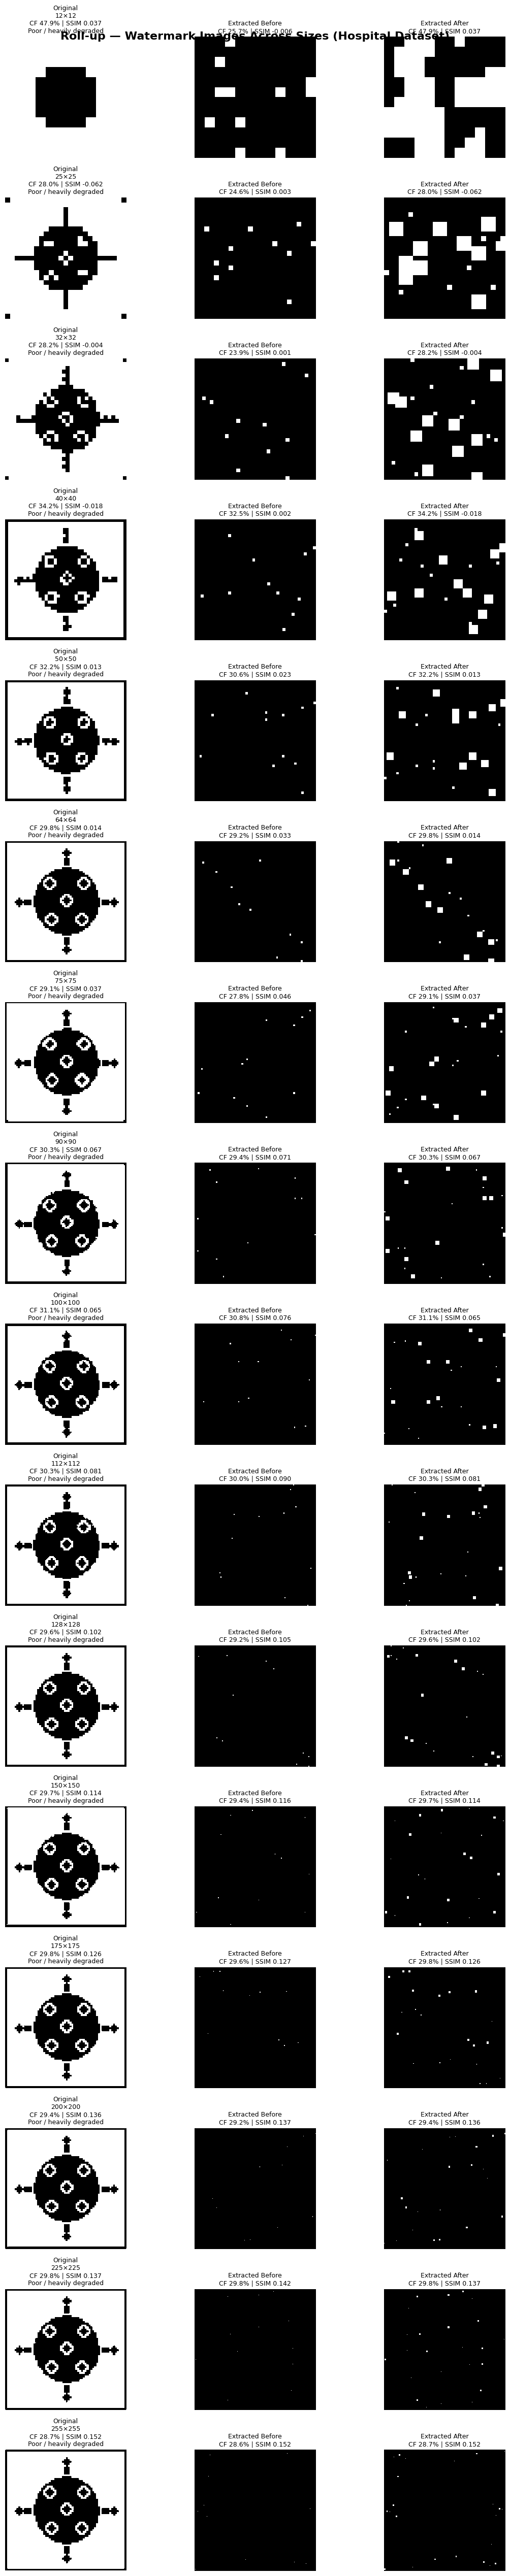

✅ Saved rollup_image_grid_hospital.png


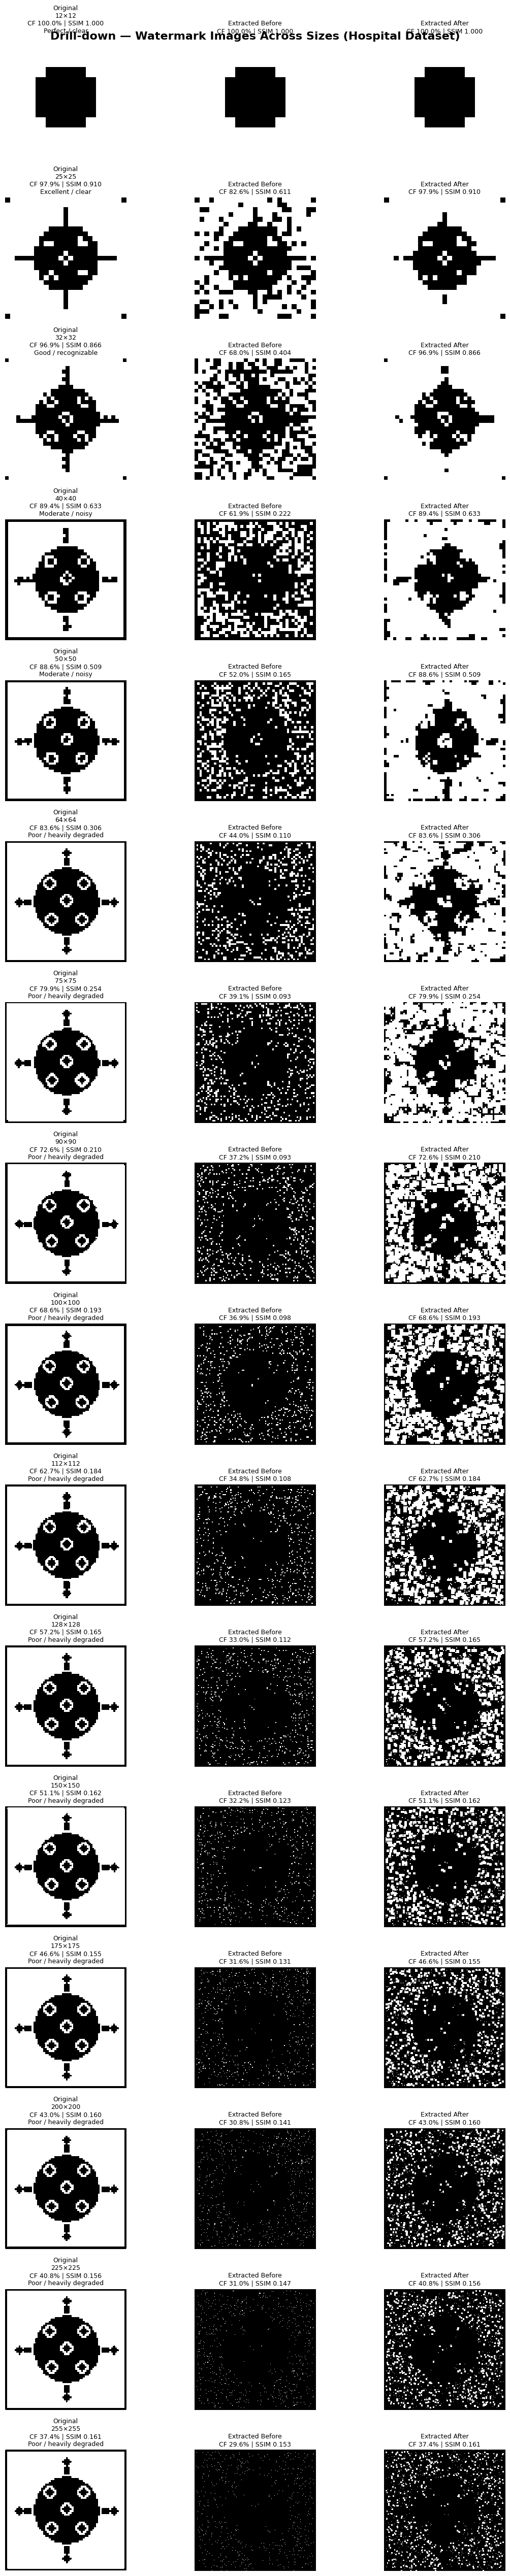

✅ Saved drilldown_image_grid_hospital.png


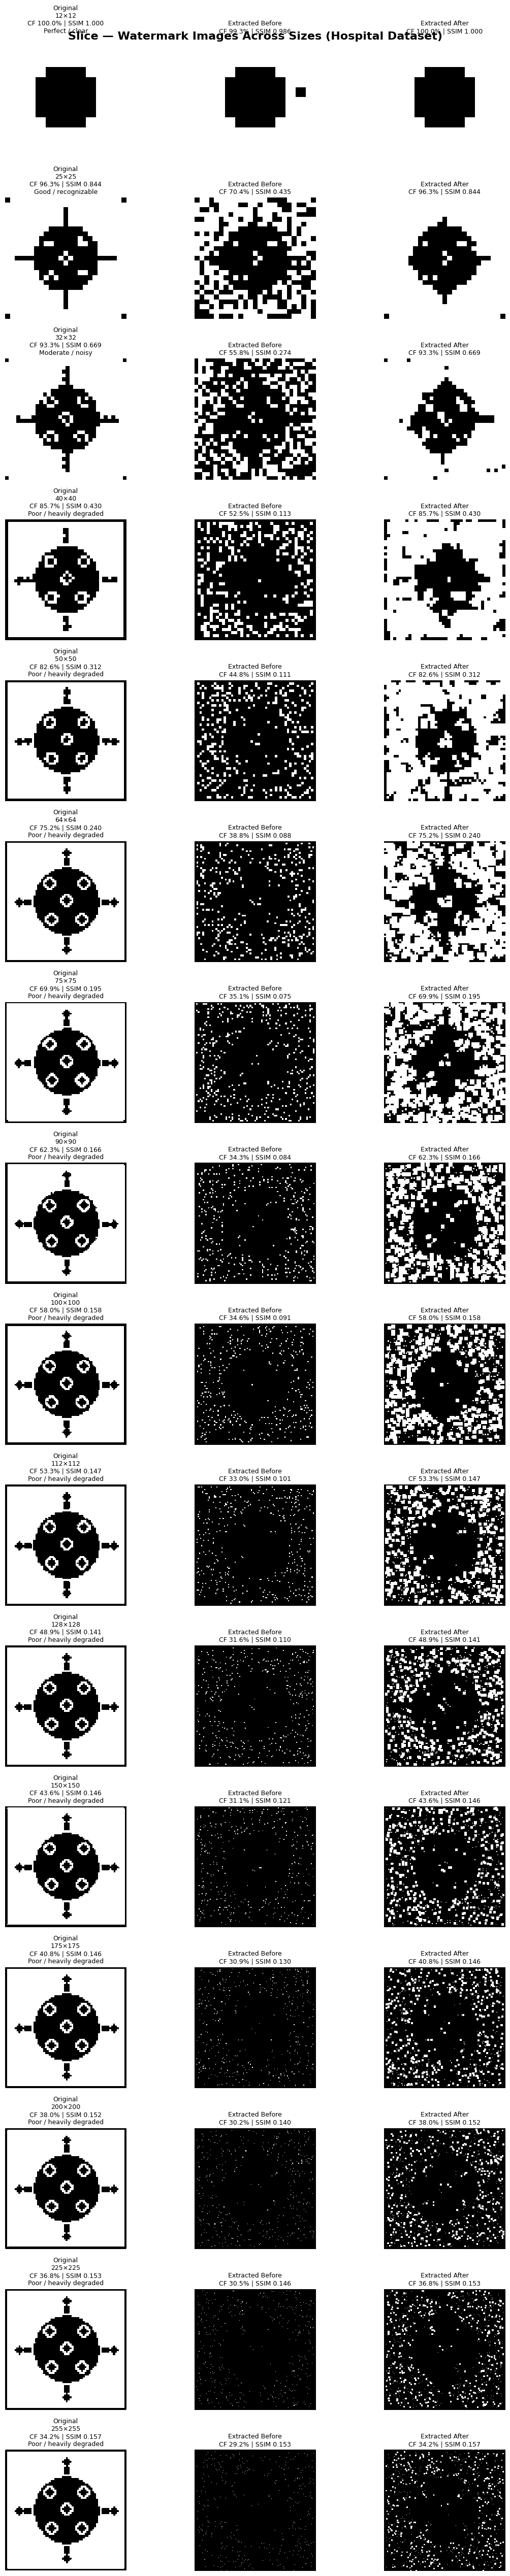

✅ Saved slice_image_grid_hospital.png


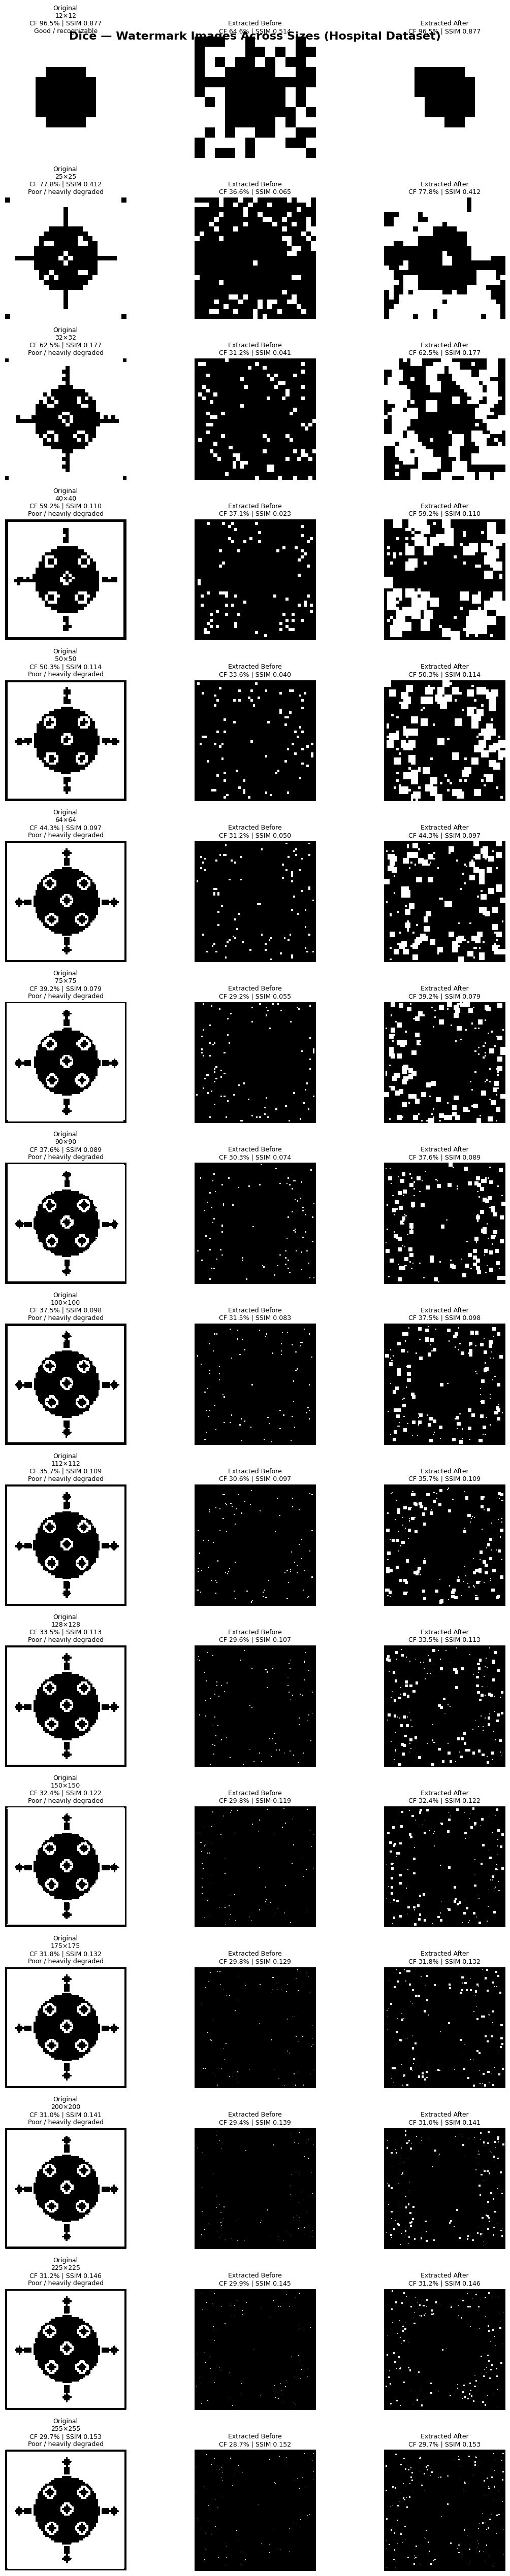

✅ Saved dice_image_grid_hospital.png


In [16]:
# ── CELL 10E — Separate grid figures for each OLAP operation (Hospital) ─────────────────

import math
import matplotlib.pyplot as plt

def build_op_view(df_wm, op_name):
    """
    Build one OLAP view from a watermarked dataframe for the hospital dataset.
    """
    df = df_wm.copy()
    df["DOA"] = pd.to_datetime(df["DOA"], errors="coerce")
    df["Month"] = df["DOA"].dt.to_period("M").astype(str)

    default_gender = df["GENDER"].dropna().iloc[0] if df["GENDER"].dropna().shape[0] > 0 else "Unknown"
    default_rural = df["RURAL"].dropna().iloc[0] if df["RURAL"].dropna().shape[0] > 0 else "Unknown"
    default_admission_type = df["ADMISSION_TYPE"].dropna().iloc[0] if df["ADMISSION_TYPE"].dropna().shape[0] > 0 else "Unknown"

    if op_name == "Roll-up":
        rolled = (
            df.groupby(["GENDER", "RURAL", "ADMISSION_TYPE", "Month"], as_index=False)
              .agg({
                  "DURATION_OF_STAY": "mean",
                  "ICU_STAY": "mean",
                  "HB": "mean",
                  "CREATININE": "mean"
              })
        )
        rolled.insert(0, "pk", range(1, len(rolled) + 1))
        rolled["DOA"] = pd.to_datetime(rolled["Month"] + "-01", errors="coerce")
        return rolled[[
            "pk", "DOA", "GENDER", "RURAL", "ADMISSION_TYPE",
            "DURATION_OF_STAY", "ICU_STAY", "HB", "CREATININE"
        ]].copy()

    elif op_name == "Drill-down":
        return df.copy()

    elif op_name == "Slice":
        return df[df["GENDER"] == default_gender].copy()

    elif op_name == "Dice":
        return df[
            (df["GENDER"] == default_gender) &
            (df["RURAL"] == default_rural) &
            (df["ADMISSION_TYPE"] == default_admission_type)
        ].copy()

    else:
        raise ValueError("Unknown operation name")


def make_image_grid_for_operation(op_name, sizes=SWEEP_SIZES):
    nrows = len(sizes)
    ncols = 3  # Original / Before / After

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(f"{op_name} — Watermark Images Across Sizes (Hospital Dataset)",
                 fontsize=16, fontweight="bold")

    for r, S in enumerate(sizes):
        # Resize watermark
        img_resized = IMG_PIL_ORIG.resize((S, S), Image.LANCZOS)
        wm_matrix = (np.array(img_resized) > 127).astype(np.uint8)

        # Embed into full dataset
        df_wm, pixel_hit, marked_count = embed_fast(wm_matrix, S, S)

        # Build OLAP view for this operation
        view_df = build_op_view(df_wm, op_name)

        # Extract and recover
        ext_raw, counts = extract_from_view(view_df, S, S)
        ext_rec = recover_image(ext_raw, counts)

        # Metrics
        cf_b = correction_factor(wm_matrix, ext_raw)
        cf_a = correction_factor(wm_matrix, ext_rec)
        ssim_b = binary_ssim(wm_matrix, ext_raw)
        ssim_a = binary_ssim(wm_matrix, ext_rec)
        status = olap_status(cf_a, ssim_a)

        # Row label
        row_label = f"{S}×{S}\nCF {cf_a:.1f}% | SSIM {ssim_a:.3f}\n{status}"

        # Plot original
        ax = axes[r, 0]
        ax.imshow(wm_matrix, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"Original\n{row_label}", fontsize=9)
        ax.axis("off")

        # Plot before recovery
        ax = axes[r, 1]
        ax.imshow(ext_raw, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"Extracted Before\nCF {cf_b:.1f}% | SSIM {ssim_b:.3f}", fontsize=9)
        ax.axis("off")

        # Plot after recovery
        ax = axes[r, 2]
        ax.imshow(ext_rec, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(f"Extracted After\nCF {cf_a:.1f}% | SSIM {ssim_a:.3f}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    out_name = f"{op_name.lower().replace('-', '').replace(' ', '_')}_image_grid_hospital.png"
    plt.savefig(out_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved {out_name}")


# Create separate grids for each operation
for op in ["Roll-up", "Drill-down", "Slice", "Dice"]:
    make_image_grid_for_operation(op, SWEEP_SIZES)

In [17]:
# ── CELL 11 — Full Sweep Report ───────────────────────────

lines = [
    "="*70,
    "  IBW WATERMARKING — SIZE SWEEP REPORT",
    "  Sardroudi & Ibrahim (2010) | Walmart Dataset",
    "="*70,
    "",
    f"  Dataset         : Walmart ({len(df)} rows)",
    f"  SECRET_KEY      : {SECRET_KEY}",
    f"  F / NUM_LSB / NUM_MSB : {F} / {NUM_LSB} / {NUM_MSB}",
    f"  Eligible rows   : {len(ELIGIBLE_PKS)}",
    f"  Sizes tested    : {SWEEP_SIZES}",
    "",
    f"{'Size':>8} | {'Pixels':>8} | {'Cover%':>7} | {'MeanHit':>8} | "
    f"{'Miss':>6} | {'CF_before':>10} | {'CF_after':>9} | {'Gain':>7}",
    "-"*80,
] + [
    f"{'→'+str(int(r['size']))+'×'+str(int(r['size'])) if int(r['size'])==BEST_SIZE else str(int(r['size']))+'×'+str(int(r['size'])):>8} | "
    f"{int(r['total_pixels']):>8,} | {r['coverage_pct']:>6.2f}% | "
    f"{r['mean_hits']:>8.2f} | {int(r['pixels_miss']):>6} | "
    f"{r['cf_before']:>9.4f}% | {r['cf_after']:>8.4f}% | {r['cf_gain']:>+6.4f}%"
    for _, r in sweep_df.iterrows()
] + [
    "",
    "="*70,
    f"  🏆 OPTIMAL SIZE : {BEST_SIZE}×{BEST_SIZE}",
    f"     CF after recovery  : {best_row['cf_after']:.4f}%",
    f"     CF before recovery : {best_row['cf_before']:.4f}%",
    f"     Recovery gain      : {best_row['cf_gain']:+.4f}%",
    f"     Pixel coverage     : {best_row['coverage_pct']:.2f}%",
    f"     Mean hits/pixel    : {best_row['mean_hits']:.2f}",
    f"     Missing pixels     : {int(best_row['pixels_miss'])}",
    "",
    "── ATTACK ROBUSTNESS AT OPTIMAL SIZE ────────────────────────────",
] + [
    f"  {int(r['Attack %']):>3}% attack  →  CF before: {r['CF Before']:>8.4f}%   CF after: {r['CF After']:>8.4f}%"
    for _, r in cf_df.iterrows()
] + ["", "="*70]

report = "\n".join(lines)
print(report)
with open('sweep_cf_report.txt', 'w') as f: f.write(report)
print("\n✅ sweep_cf_report.txt saved")

  IBW WATERMARKING — SIZE SWEEP REPORT
  Sardroudi & Ibrahim (2010) | Walmart Dataset

  Dataset         : Walmart (9841 rows)
  SECRET_KEY      : walmart_ibw_2024
  F / NUM_LSB / NUM_MSB : 5 / 4 / 2
  Eligible rows   : 927
  Sizes tested    : [12, 25, 32, 40, 50, 64, 75, 90, 100, 112, 128, 150, 175, 200, 225, 255]

    Size |   Pixels |  Cover% |  MeanHit |   Miss |  CF_before |  CF_after |    Gain
--------------------------------------------------------------------------------
  →12×12 |      144 | 100.00% |     6.44 |      0 |  100.0000% | 100.0000% | +0.0000%
   25×25 |      625 |  76.64% |     1.48 |    146 |   82.5600% |  97.9200% | +15.3600%
   32×32 |    1,024 |  58.59% |     0.91 |    424 |   67.9688% |  96.8750% | +28.9062%
   40×40 |    1,600 |  43.81% |     0.58 |    899 |   61.8750% |  89.4375% | +27.5625%
   50×50 |    2,500 |  30.84% |     0.37 |   1729 |   52.0400% |  88.6400% | +36.6000%
   64×64 |    4,096 |  20.29% |     0.23 |   3265 |   44.0430% |  83.6426% | +39.5

In [ ]:
# ── CELL 12 — Download All Outputs ───────────────────────
for fname in [
    'original_walmart.csv',
    'watermarked_walmart.csv',
    'size_sweep_results.csv',
    'attack_cf_results_optimal.csv',
    'sweep_cf_report.txt',
    'sweep_analysis.png',
    'sweep_visual_grid.png',
    'extraction_optimal.png',
    'extracted_watermark_optimal.png',
    'attack_robustness_optimal.png',
]:
    try:
        files.download(fname)
        print(f"✅ {fname}")
    except Exception as e:
        print(f"⚠️  {fname} — {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ original_walmart.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ extracted_watermark_optimal.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ attack_robustness_optimal.png
